In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

repo = Path(r"C:\Users\k1van\Mingl")

output_dir = (
    repo / "border_figures" / "outputs" / "figure2_threshold_effects"
)
analysis_dir = output_dir / "updated_percentage_analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

conditions = pd.read_csv(output_dir / "conditions.csv")

# Important: this is the ALL-border summary, not the selected-pair summary.
general_path = output_dir / "threshold_summary_GENERAL.csv"

if not general_path.exists():
    raise FileNotFoundError(
        "The all-border summary is missing. Locate threshold_summary_GENERAL.csv "
        "from the completed sweep; do not substitute threshold_summary.csv."
    )

general_summary = pd.read_csv(general_path)

# Exclude the randomized null condition.
null_flags = conditions["is_null"].astype(str).str.lower()
if not null_flags.isin(["true", "false"]).all():
    raise ValueError("Unexpected is_null values in conditions.csv.")

real_conditions = conditions.loc[null_flags.eq("false")].copy()

if real_conditions["condition"].duplicated().any():
    raise ValueError("Duplicate condition identifiers.")

condition_order = real_conditions["condition"].tolist()
condition_labels = real_conditions.set_index("condition")["label"].to_dict()
condition_colors = dict(zip(condition_order, sns.color_palette("tab10", len(condition_order))))

display(
    real_conditions[
        ["condition", "label", "dataset", "level", "cn1", "cn2", "n_cells"]
    ]
)


def save_plot(fig, name):
    fig.savefig(
        analysis_dir / f"{name}.png", dpi=300, bbox_inches="tight"
    )
    fig.savefig(
        analysis_dir / f"{name}.pdf", bbox_inches="tight"
    )
    plt.show()
    plt.close(fig)


def read_threshold_matrix(path):
    """
    Read wide threshold × cell-type CSVs.
    The collaborator's files may have an unnamed first index column.
    """
    matrix = pd.read_csv(path, index_col=0)
    matrix.index = pd.to_numeric(matrix.index, errors="raise")
    matrix.index.name = "threshold"
    matrix = matrix.apply(pd.to_numeric, errors="raise").sort_index()

    if matrix.index.duplicated().any():
        raise ValueError(f"Duplicate thresholds in {path.name}.")

    return matrix

,condition,label,dataset,level,cn1,cn2,n_cells
1,intestine_neighborhood,Intestine · cellular neighborhood,intestine,neighborhood,Inner Follicle,Outer Follicle,2512002
2,intestine_community,Intestine · community,intestine,community,Secretory Epithelial,Plasma Cell Enriched,2512002
3,intestine_tissue_unit,Intestine · tissue unit,intestine,tissue_unit,Mucosa,Muscularis mucosa,2512002
4,melanoma_neighborhood,Melanoma · cellular neighborhood,melanoma,neighborhood,Inflamed Tumor,Productive T cell & Tumor,5019159
5,spatial_tissue,Mouse brain · anatomical region,spatial,tissue,cortical layer VI,corpus callosum,378918


In [5]:
general_summary

,threshold,n_border,frac_border,mean_positive,n_regions_with_border,centroid_x,centroid_y,spread_x,spread_y,condition,label,dataset,level,is_null
0,0.01,2360909,0.939852,11.015625,64,4771.073929,4670.432220,2587.068340,2529.056600,intestine_null,Intestine · null,intestine,neighborhood,True
1,0.05,2205948,0.878163,4.185655,64,4766.641264,4662.578567,2588.686409,2528.928392,intestine_null,Intestine · null,intestine,neighborhood,True
2,0.10,1810557,0.720763,2.229679,64,4771.617551,4655.530670,2592.583979,2532.388322,intestine_null,Intestine · null,intestine,neighborhood,True
3,0.15,1095553,0.436127,1.458000,64,4785.125001,4639.143961,2597.796795,2538.695859,intestine_null,Intestine · null,intestine,neighborhood,True
4,0.20,602157,0.239712,1.105791,64,4785.118262,4629.786488,2596.264131,2538.208187,intestine_null,Intestine · null,intestine,neighborhood,True
5,0.25,301953,0.120204,0.883065,64,4768.974741,4634.400834,2577.756307,2534.755923,intestine_null,Intestine · null,intestine,neighborhood,True
6,0.33,82114,0.032689,0.650616,64,4744.944163,4681.286102,2545.105825,2523.725008,intestine_null,Intestine · null,intestine,neighborhood,True
7,0.40,14688,0.005847,0.517010,64,4690.708878,4677.585784,2528.025813,2536.668136,intestine_null,Intestine · null,intestine,neighborhood,True
8,0.49,80,0.000032,0.381811,35,5076.375000,4830.287500,2535.111158,2732.718039,intestine_null,Intestine · null,intestine,neighborhood,True
9,0.01,1096690,0.436580,1.716545,64,4744.360748,4715.314697,2557.795119,2518.623404,intestine_neighborhood,Intestine · cellular neighborhood,intestine,neighborhood,False


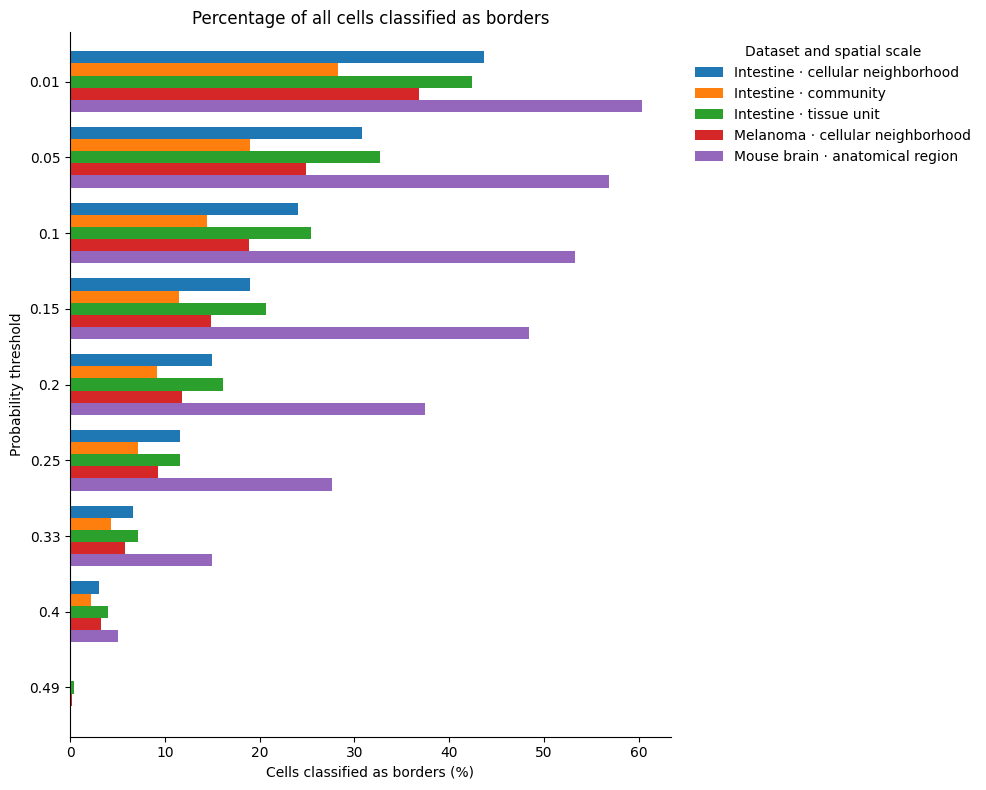

In [2]:
border_percent = general_summary.loc[
    general_summary["condition"].isin(condition_order)
].copy()

required = {"condition", "threshold", "n_border"}
if not required.issubset(border_percent.columns):
    raise ValueError(f"Missing columns: {required - set(border_percent.columns)}")

# The supplied driver exports a global summary per condition and threshold.
# Reject duplicates rather than accidentally adding repeated totals.
if border_percent.duplicated(["condition", "threshold"]).any():
    raise ValueError(
        "Multiple rows per condition and threshold. "
        "Inspect whether these are regional or duplicate summaries."
    )

denominators = real_conditions.set_index("condition")["n_cells"]
border_percent["total_cells"] = border_percent["condition"].map(denominators)

if (
    border_percent["total_cells"].isna().any()
    or (border_percent["total_cells"] <= 0).any()
):
    raise ValueError("Missing or invalid total-cell denominators.")

if (
    (border_percent["n_border"] < 0)
    | (border_percent["n_border"] > border_percent["total_cells"])
).any():
    raise ValueError("Border counts are outside the valid range.")

border_percent["percent_border"] = (
    100 * border_percent["n_border"] / border_percent["total_cells"]
)

percent_matrix = border_percent.pivot(
    index="threshold",
    columns="condition",
    values="percent_border",
).sort_index().reindex(columns=condition_order)

if percent_matrix.isna().any().any():
    raise ValueError("Conditions do not have a complete shared threshold grid.")

fig, ax = plt.subplots(figsize=(10, 8))

plot_matrix = percent_matrix.rename(columns=condition_labels)
plot_matrix.index = [f"{t:g}" for t in percent_matrix.index]

plot_matrix.plot.barh(
    ax=ax,
    color=[condition_colors[c] for c in condition_order],
    width=0.8,
    edgecolor="none",
)

ax.invert_yaxis()
ax.set_xlabel("Cells classified as borders (%)")
ax.set_ylabel("Probability threshold")
ax.set_title("Percentage of all cells classified as borders")
ax.legend(
    title="Dataset and spatial scale",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
save_plot(fig, "panel_b_percent_border")

border_percent.to_csv(
    analysis_dir / "all_border_percentages.csv", index=False
)

threshold,0.01,0.10,0.20,0.25,0.49
threshold,,,,,
0.01,1.000000,0.972308,0.950769,0.940000,0.885385
0.10,0.972308,1.000000,0.989231,0.977692,0.926154
0.20,0.950769,0.989231,1.000000,0.993077,0.952308
0.25,0.940000,0.977692,0.993077,1.000000,0.963846
0.49,0.885385,0.926154,0.952308,0.963846,1.000000


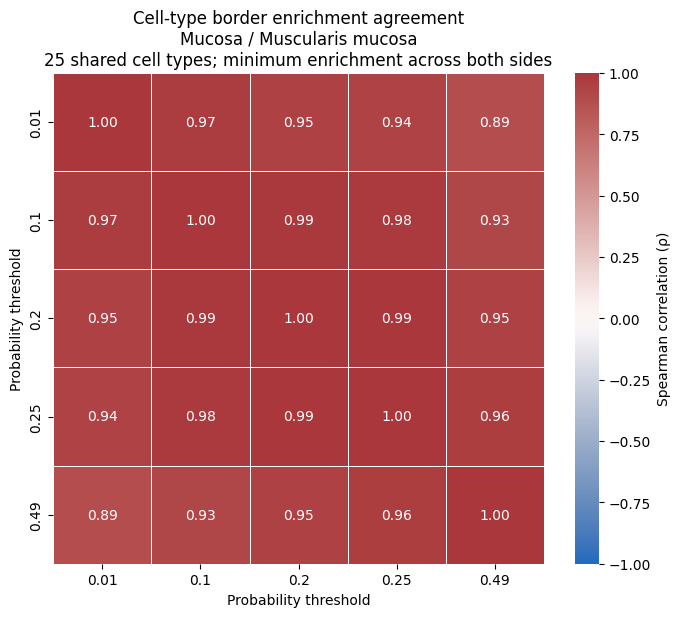

In [3]:
# Select the intestine tissue-unit condition shown in h–l.
candidates = real_conditions.loc[
    real_conditions["dataset"].eq("intestine")
    & real_conditions["level"].eq("tissue_unit")
]

if len(candidates) != 1:
    raise ValueError(
        "Select the intended intestine tissue-unit condition explicitly."
    )

condition = candidates.iloc[0]
condition_name = condition["condition"]

enrichment = read_threshold_matrix(
    output_dir / f"enrichment_{condition_name}.csv"
)

# These are the five thresholds currently shown in h–l.
# Use enrichment.index.tolist() instead to include every saved threshold.
requested_thresholds = [0.01, 0.10, 0.20, 0.25, 0.49]

selected_thresholds = []
for threshold in requested_thresholds:
    matches = enrichment.index[
        np.isclose(enrichment.index.to_numpy(), threshold)
    ]
    if len(matches) != 1:
        raise ValueError(f"Missing or ambiguous threshold {threshold}.")
    selected_thresholds.append(matches[0])

selected = enrichment.loc[selected_thresholds].copy()

# Use the same cell types for every correlation.
valid_types = np.isfinite(selected.to_numpy()).all(axis=0)
selected = selected.loc[:, valid_types]

if selected.shape[1] < 3:
    raise ValueError("Fewer than three cell types have finite scores at all thresholds.")

# Exclude undefined comparisons rather than converting NaN/inf to zero.
constant_rows = selected.nunique(axis=1) < 2
if constant_rows.any():
    raise ValueError(
        f"Constant enrichment vectors at thresholds: "
        f"{selected.index[constant_rows].tolist()}"
    )

# Columns are thresholds; observations are cell types.
correlation = selected.T.corr(method="spearman")

display(correlation)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    xticklabels=[f"{t:g}" for t in correlation.columns],
    yticklabels=[f"{t:g}" for t in correlation.index],
    cbar_kws={"label": "Spearman correlation (ρ)"},
    ax=ax,
)

ax.set_xlabel("Probability threshold")
ax.set_ylabel("Probability threshold")
ax.set_title(
    f"Cell-type border enrichment agreement\n"
    f"{condition['cn1']} / {condition['cn2']}\n"
    f"{selected.shape[1]} shared cell types; minimum enrichment across both sides"
)

fig.tight_layout()
save_plot(fig, "threshold_enrichment_spearman")

selected.to_csv(analysis_dir / "enrichment_values_for_correlation.csv")
correlation.to_csv(analysis_dir / "threshold_enrichment_spearman.csv")

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd

OUTPUT = Path(r"C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects")

for path in sorted(OUTPUT.glob("*.csv")):
    preview = pd.read_csv(path, nrows=2)
    print(f"\n{path.name}")
    print(preview.columns.tolist())


composition_GENERAL_intestine_community.csv
['threshold', 'B', 'CD4+ T cell', 'CD57+ Enterocyte', 'CD66+ Enterocyte', 'CD7+ Immune', 'CD8+ T', 'Cycling TA', 'DC', 'Endothelial', 'Enterocyte', 'Goblet', 'ICC', 'Lymphatic', 'M1 Macrophage', 'M2 Macrophage', 'MUC1+ Enterocyte', 'NK', 'Nerve', 'Neuroendocrine', 'Neutrophil', 'Paneth', 'Plasma', 'Smooth muscle', 'Stroma', 'TA']

composition_GENERAL_intestine_neighborhood.csv
['threshold', 'B', 'CD4+ T cell', 'CD57+ Enterocyte', 'CD66+ Enterocyte', 'CD7+ Immune', 'CD8+ T', 'Cycling TA', 'DC', 'Endothelial', 'Enterocyte', 'Goblet', 'ICC', 'Lymphatic', 'M1 Macrophage', 'M2 Macrophage', 'MUC1+ Enterocyte', 'NK', 'Nerve', 'Neuroendocrine', 'Neutrophil', 'Paneth', 'Plasma', 'Smooth muscle', 'Stroma', 'TA']

composition_GENERAL_intestine_null.csv
['threshold', 'B', 'CD4+ T cell', 'CD57+ Enterocyte', 'CD66+ Enterocyte', 'CD7+ Immune', 'CD8+ T', 'Cycling TA', 'DC', 'Endothelial', 'Enterocyte', 'Goblet', 'ICC', 'Lymphatic', 'M1 Macrophage', 'M2 Macr

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path

OUTPUT = Path(OUTPUT)

conditions = pd.read_csv(OUTPUT / "conditions.csv")
general_summary = pd.read_csv(OUTPUT / "threshold_summary_GENERAL.csv")
pair_summary = pd.read_csv(OUTPUT / "threshold_summary.csv")

# Panel b: percentage of ALL analyzed cells classified as borders.
general_summary["percent_border"] = (
    100 * general_summary["frac_border"]
)

# Separate quantity: percentage of all cells at the SELECTED border.
pair_summary["percent_selected_border"] = (
    100 * pair_summary["frac_border"]
)

def load_threshold_table(path):
    # Handles both "threshold" and "Unnamed: 0" index columns.
    table = pd.read_csv(path, index_col=0)
    table.index = pd.to_numeric(table.index, errors="raise")
    table.index.name = "threshold"
    return table.sort_index()

pair_compositions = {}
general_compositions = {}
minimum_enrichments = {}

for condition in conditions["condition"]:
    files = {
        "pair": OUTPUT / f"composition_{condition}.csv",
        "general": OUTPUT / f"composition_GENERAL_{condition}.csv",
        "minimum": OUTPUT / f"enrichment_{condition}.csv",
    }

    if files["pair"].exists():
        pair_compositions[condition] = load_threshold_table(files["pair"])

    if files["general"].exists():
        general_compositions[condition] = load_threshold_table(files["general"])

    if files["minimum"].exists():
        minimum_enrichments[condition] = load_threshold_table(files["minimum"])

display(
    general_summary[
        ["condition", "threshold", "n_border", "percent_border"]
    ].head(15)
)

,condition,threshold,n_border,percent_border
0,intestine_null,0.01,2360909,93.985156
1,intestine_null,0.05,2205948,87.816331
2,intestine_null,0.10,1810557,72.076256
3,intestine_null,0.15,1095553,43.612744
4,intestine_null,0.20,602157,23.971199
5,intestine_null,0.25,301953,12.020412
6,intestine_null,0.33,82114,3.268867
7,intestine_null,0.40,14688,0.584713
8,intestine_null,0.49,80,0.003185
9,intestine_neighborhood,0.01,1096690,43.658007


In [9]:
# The original workflow may have cached probabilities in a sibling _cache folder.
CACHE_DIR = OUTPUT.parent / "_cache"

if CACHE_DIR.exists():
    cache_files = sorted(
        path for path in CACHE_DIR.rglob("*")
        if path.is_file()
    )
    print(f"Found {len(cache_files)} cached files:")
    for path in cache_files[:100]:
        print(path)
else:
    print(f"No cache directory found at: {CACHE_DIR}")

Found 6 cached files:
C:\Users\k1van\Mingl\border_figures\outputs\_cache\posterior_intestine_community_diagonal_gaussian_d78d7dbf0aebaac2.npz
C:\Users\k1van\Mingl\border_figures\outputs\_cache\posterior_intestine_neighborhood_diagonal_gaussian_3db5669a5700afbb.npz
C:\Users\k1van\Mingl\border_figures\outputs\_cache\posterior_intestine_neighborhood_diagonal_gaussian_725962ddc4f94dc7.npz
C:\Users\k1van\Mingl\border_figures\outputs\_cache\posterior_intestine_tissue_unit_diagonal_gaussian_84e896629c027337.npz
C:\Users\k1van\Mingl\border_figures\outputs\_cache\posterior_melanoma_neighborhood_diagonal_gaussian_4c863e3672d202c6.npz
C:\Users\k1van\Mingl\border_figures\outputs\_cache\posterior_spatial_tissue_diagonal_gaussian_a680ef745d5ac797.npz


In [10]:
from pathlib import Path
import zipfile
import numpy as np

CACHE_DIR = Path(
    r"C:\Users\k1van\Mingl\border_figures\outputs\_cache"
)

cache_path = CACHE_DIR / (
    "posterior_intestine_tissue_unit_diagonal_gaussian_"
    "84e896629c027337.npz"
)

with zipfile.ZipFile(cache_path) as archive:
    for member in archive.namelist():
        if not member.endswith(".npy"):
            continue

        with archive.open(member) as stream:
            version = np.lib.format.read_magic(stream)

            if version == (1, 0):
                shape, fortran_order, dtype = (
                    np.lib.format.read_array_header_1_0(stream)
                )
            elif version == (2, 0):
                shape, fortran_order, dtype = (
                    np.lib.format.read_array_header_2_0(stream)
                )
            else:
                print(f"{member}: unsupported header version {version}")
                continue

        print(
            f"{member.removesuffix('.npy')}: "
            f"shape={shape}, dtype={dtype}"
        )

probs: shape=(2512002, 4), dtype=float64
units: shape=(4,), dtype=object


In [11]:
conditions = pd.read_csv(OUTPUT / "conditions.csv")

display(
    conditions.loc[
        conditions["condition"] == "intestine_tissue_unit"
    ]
)

,condition,label,dataset,level,unit_col,feature_col,k,is_null,cn1,cn2,n_cells
3,intestine_tissue_unit,Intestine · tissue unit,intestine,tissue_unit,Tissue Unit,Community,300,False,Mucosa,Muscularis mucosa,2512002


In [12]:
import numpy as np
import pandas as pd

# allow_pickle=True is needed for the object-dtype unit names.
# Use this only for your own trusted cache.
with np.load(cache_path, allow_pickle=True) as saved:
    tissue_probs = saved["probs"]
    tissue_units = [str(unit) for unit in saved["units"]]

print("Probability matrix:", tissue_probs.shape)
print("Tissue units:", tissue_units)

if tissue_probs.shape != (2512002, len(tissue_units)):
    raise ValueError("Unexpected probability matrix shape.")

if len(set(tissue_units)) != len(tissue_units):
    raise ValueError("Duplicate tissue-unit names.")

Probability matrix: (2512002, 4)
Tissue units: ['Mucosa', 'Muscularis externa', 'Muscularis mucosa', 'Submucosa']


starting here

In [1]:
from pathlib import Path

import anndata as ad
import mingl as mg
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Original input data.
INTESTINE_PATH = Path(
    r"Z:\MINGLE\Data\Intestine\05_25_HuBMAP_tunit.csv"
)

# Folder containing your existing threshold-summary/composition CSVs.
SAVED = Path(
    r"C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects"
)

# Save revised outputs separately.
OUTPUT = SAVED / "updated_threshold_figure"
OUTPUT.mkdir(parents=True, exist_ok=True)

CELL_TYPE_COL = "Cell Type"   # Check against the printed columns below.
COMMUNITY_COL = "Community"
TISSUE_UNIT_COL = "Tissue Unit"
REGION_KEY = "unique_region"
X_KEY = "x"
Y_KEY = "y"

N1 = "Mucosa"
N2 = "Muscularis mucosa"

THRESHOLDS = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.33, 0.40, 0.49]
HEATMAP_THRESHOLDS = [0.01, 0.10, 0.20, 0.25, 0.33, 0.49]
MIN_COUNT = 10
EPS = 1e-9

CONDITIONS = {
    "intestine_neighborhood": "Intestine – Cell Neighborhood",
    "intestine_community": "Intestine – Community",
    "intestine_tissue_unit": "Intestine – Tissue Unit",
    "melanoma_neighborhood": "Melanoma – Cell Neighborhood",
    "spatial_tissue": "Mouse Brain – Cell Neighborhood",
}

CONDITION_COLORS = dict(
    zip(CONDITIONS, plt.get_cmap("tab10").colors[:len(CONDITIONS)])
)

def finish_figure(fig, name):
    fig.savefig(OUTPUT / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTPUT / f"{name}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Input annotation columns:")
print(pd.read_csv(INTESTINE_PATH, nrows=0).columns.tolist())

Input annotation columns:
['Unnamed: 0', 'MUC2', 'SOX9', 'MUC1', 'CD31', 'Synapto', 'CD49f', 'CD15', 'CHGA', 'CDX2', 'ITLN1', 'CD4', 'CD127', 'Vimentin', 'HLADR', 'CD8', 'CD11c', 'CD44', 'CD16', 'BCL2', 'CD3', 'CD123', 'CD38', 'CD90', 'aSMA', 'CD21', 'NKG2D', 'CD66', 'CD57', 'CD206', 'CD68', 'CD34', 'aDef5', 'CD7', 'CD36', 'CD138', 'CD45RO', 'Cytokeratin', 'CD117', 'CD19', 'Podoplanin', 'CD45', 'CD56', 'CD69', 'Ki67', 'CD49a', 'CD163', 'CD161', 'first_index', 'x', 'y', 'tissue', 'donor', 'region', 'OLFM4', 'FAP', 'CD25', 'CollIV', 'CK7', 'Xcorr', 'Ycorr', 'unique_region', 'neigh_name', 'neigh_sub1', 'Preservation_method', 'Tissue_location', 'array', 'Cell Type', 'Cell Type em', 'Cell subtype', 'machine', 'MUC6', 'Neighborhood', 'Neighborhood_Ind', 'Neigh_sub', 'NeighInd_sub', 'Community', 'Major Community', 'Tissue Segment', 'Tissue Unit']


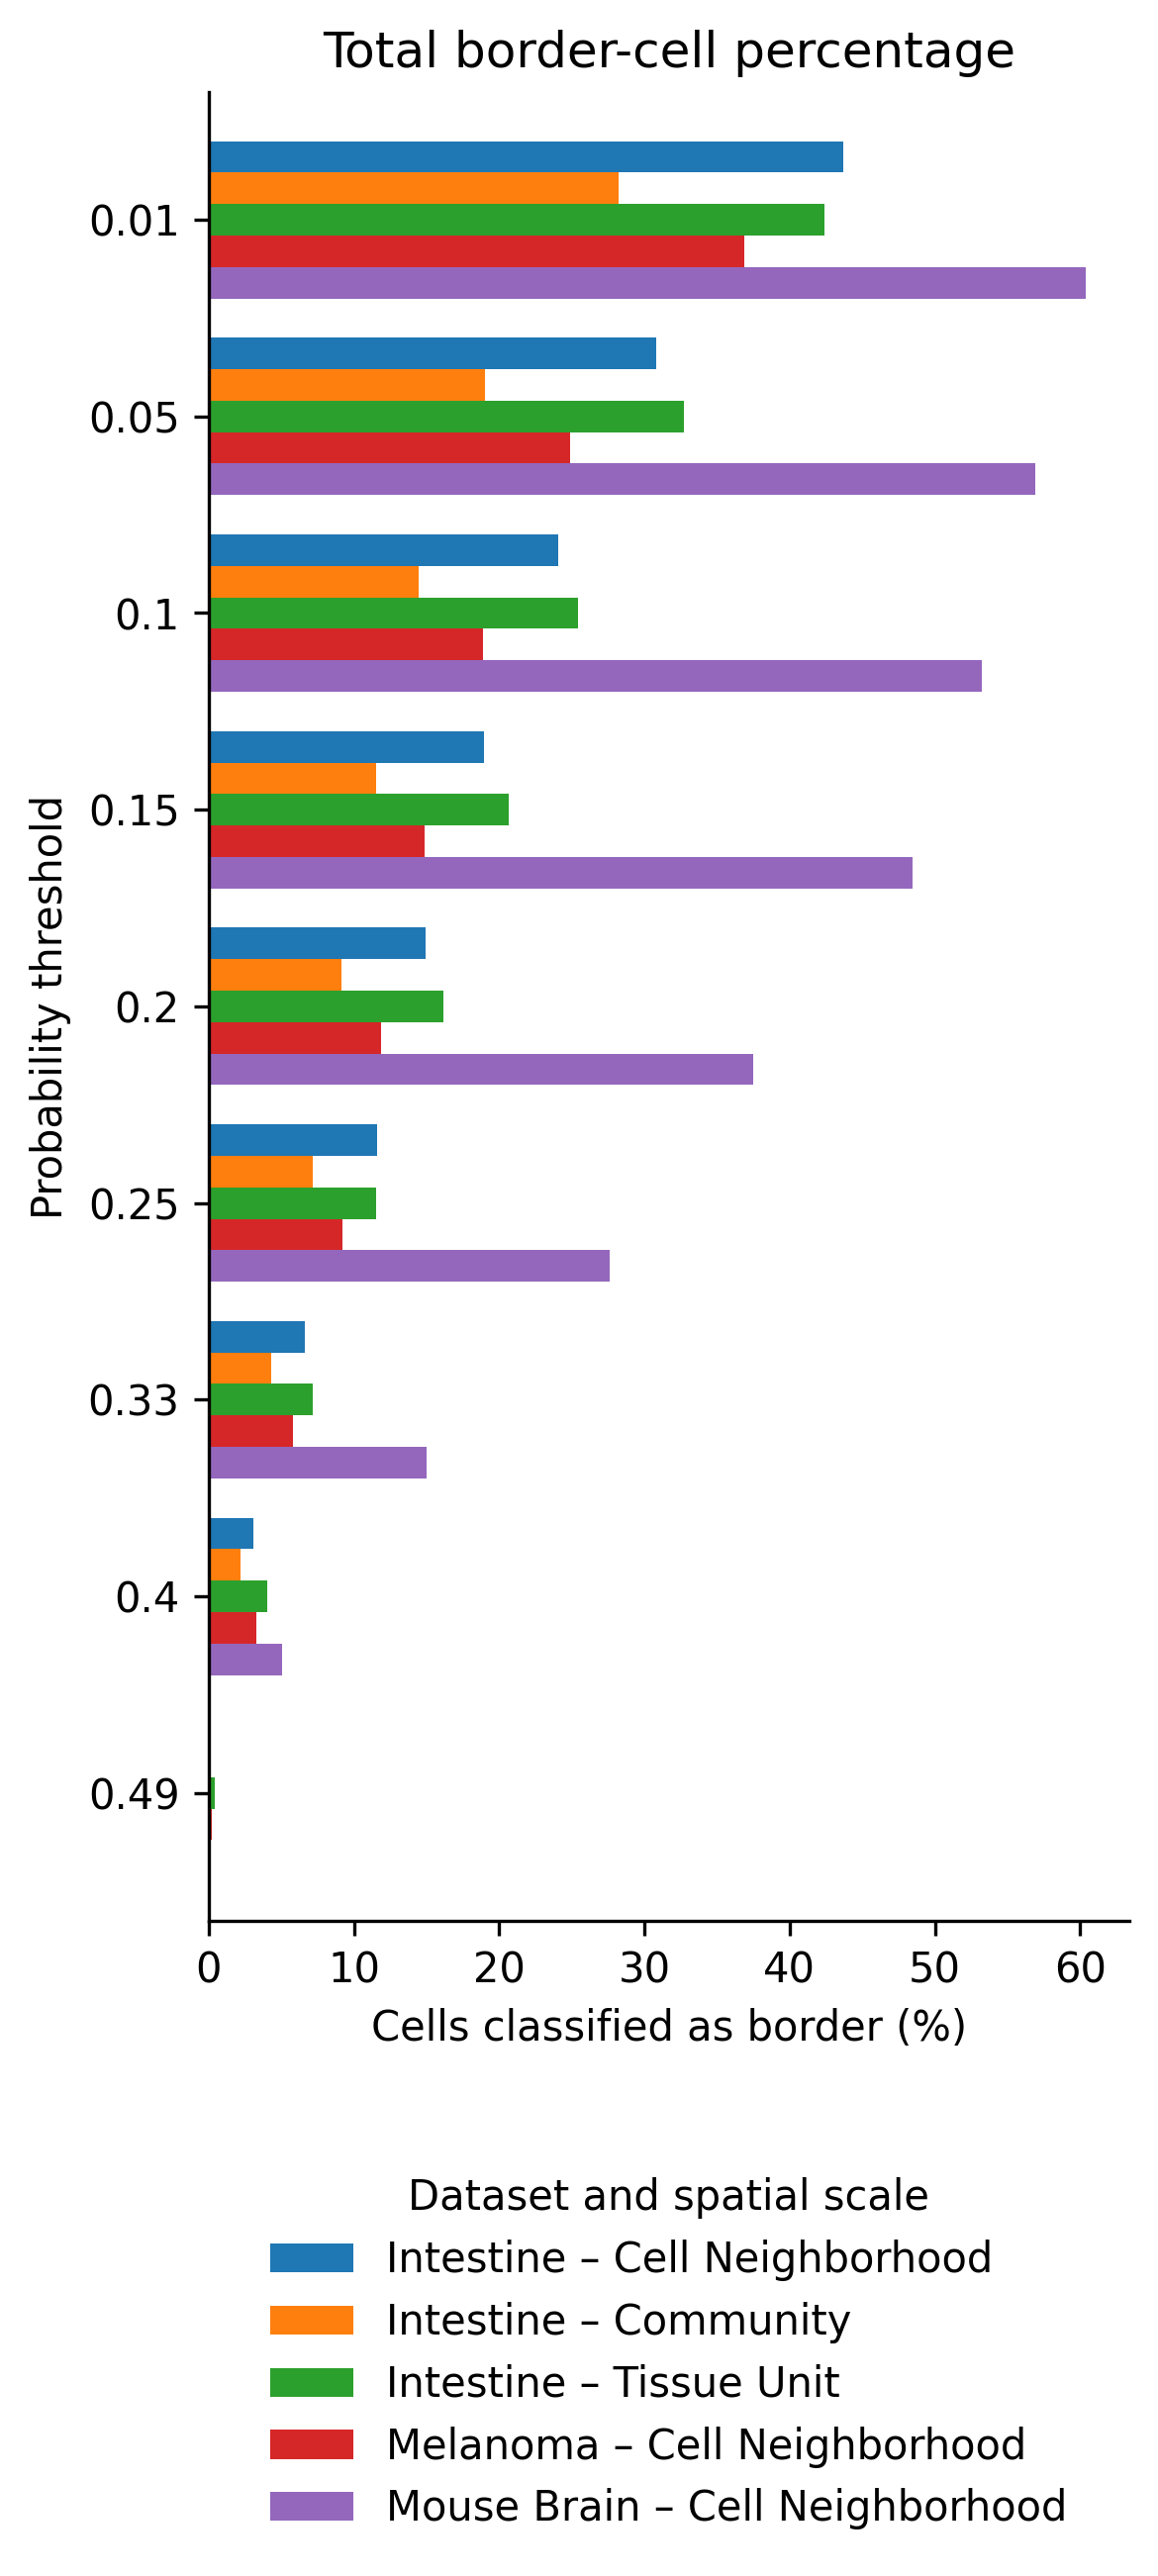

In [2]:
general = pd.read_csv(SAVED / "threshold_summary_GENERAL.csv")
general = general.loc[general["condition"].isin(CONDITIONS)].copy()

if general.duplicated(["condition", "threshold"]).any():
    raise ValueError("Duplicate condition/threshold rows in the general summary.")

general["threshold"] = pd.to_numeric(general["threshold"])
general["percent_border"] = 100 * general["frac_border"]

percent_border = general.pivot(
    index="threshold",
    columns="condition",
    values="percent_border",
).sort_index().reindex(columns=list(CONDITIONS))

percent_border.to_csv(OUTPUT / "percent_border_by_threshold.csv")

fig, ax = plt.subplots(figsize=(4, 8), dpi=300)

percent_border.rename(columns=CONDITIONS).plot.barh(
    ax=ax,
    color=[CONDITION_COLORS[c] for c in CONDITIONS],
    width=0.8,
)

ax.invert_yaxis()
ax.set_xlabel("Cells classified as border (%)")
ax.set_ylabel("Probability threshold")
ax.set_title("Total border-cell percentage")
ax.spines[["top", "right"]].set_visible(False)

ax.legend(
    title="Dataset and spatial scale",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    frameon=False,
    ncol=1,
)

finish_figure(fig, "panel_b_percent_border")

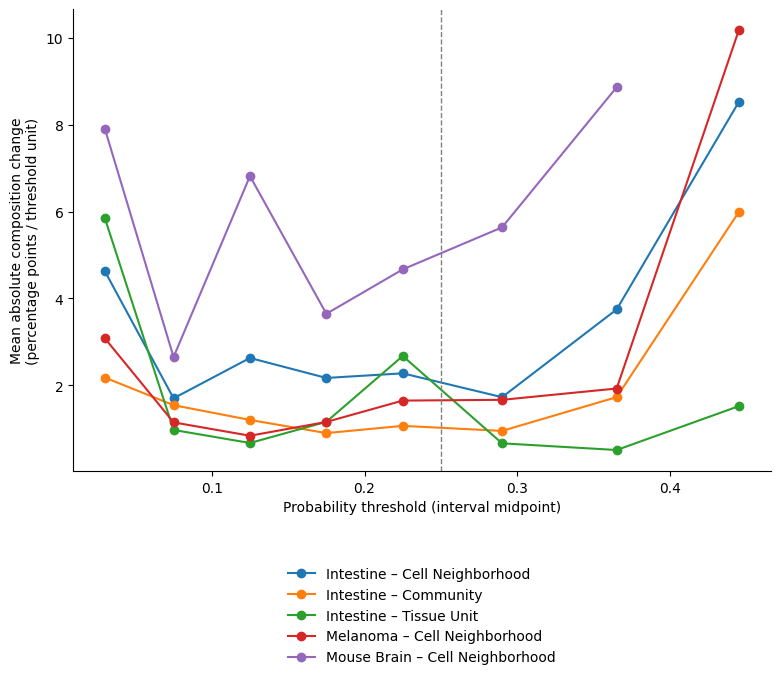

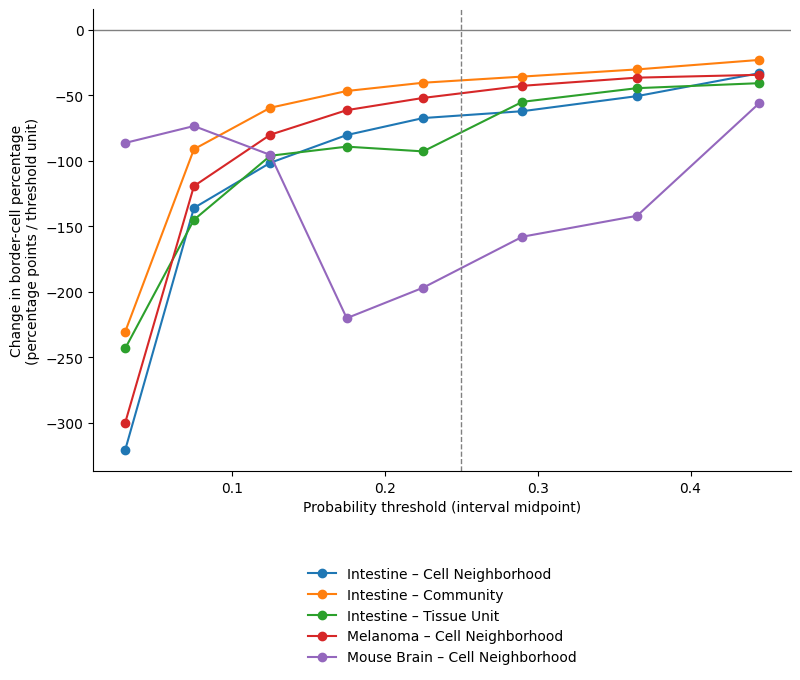

In [3]:
def load_composition(condition):
    table = pd.read_csv(
        SAVED / f"composition_{condition}.csv",
        index_col=0,
    )
    table.index = pd.to_numeric(table.index)
    table.index.name = "threshold"
    table = table.sort_index().astype(float)

    if table.index.has_duplicates:
        raise ValueError(f"{condition}: duplicate thresholds.")

    return table


composition_sensitivity = []
border_sensitivity = []

for condition in CONDITIONS:
    # Panel m: composition within the selected interface.
    composition = load_composition(condition)
    t = composition.index.to_numpy(dtype=float)
    values = composition.to_numpy() * 100

    dt = np.diff(t)
    if np.any(dt <= 0):
        raise ValueError(f"{condition}: thresholds must increase.")

    valid = (
        np.isfinite(values).all(axis=1)
        & np.isclose(values.sum(axis=1), 100, atol=1e-4)
    )

    slopes = np.diff(values, axis=0) / dt[:, None]
    mean_absolute_slopes = np.mean(np.abs(slopes), axis=1)
    mean_absolute_slopes[~(valid[:-1] & valid[1:])] = np.nan

    for i, slope in enumerate(mean_absolute_slopes):
        composition_sensitivity.append({
            "condition": condition,
            "threshold_low": t[i],
            "threshold_high": t[i + 1],
            "threshold_midpoint": (t[i] + t[i + 1]) / 2,
            "mean_absolute_composition_slope": slope,
        })

    # Panel n: percentage of all cells classified as borders.
    summary = general.loc[
        general["condition"] == condition
    ].sort_values("threshold")

    t = summary["threshold"].to_numpy(dtype=float)
    percentages = summary["percent_border"].to_numpy(dtype=float)

    for i, slope in enumerate(np.diff(percentages) / np.diff(t)):
        border_sensitivity.append({
            "condition": condition,
            "threshold_low": t[i],
            "threshold_high": t[i + 1],
            "threshold_midpoint": (t[i] + t[i + 1]) / 2,
            "border_percentage_slope": slope,
        })

composition_sensitivity = pd.DataFrame(composition_sensitivity)
border_sensitivity = pd.DataFrame(border_sensitivity)

composition_sensitivity.to_csv(
    OUTPUT / "composition_percentage_sensitivity.csv", index=False
)
border_sensitivity.to_csv(
    OUTPUT / "border_percentage_sensitivity.csv", index=False
)

for table, value_col, ylabel, filename in [
    (
        composition_sensitivity,
        "mean_absolute_composition_slope",
        "Mean absolute composition change\n"
        "(percentage points / threshold unit)",
        "panel_m_composition_sensitivity",
    ),
    (
        border_sensitivity,
        "border_percentage_slope",
        "Change in border-cell percentage\n"
        "(percentage points / threshold unit)",
        "panel_n_border_percentage_sensitivity",
    ),
]:
    fig, ax = plt.subplots(figsize=(9, 6))

    for condition, label in CONDITIONS.items():
        subset = table.loc[table["condition"] == condition]
        ax.plot(
            subset["threshold_midpoint"],
            subset[value_col],
            marker="o",
            color=CONDITION_COLORS[condition],
            label=label,
        )

    ax.axvline(0.25, color="gray", linestyle="--", linewidth=1)
    if value_col == "border_percentage_slope":
        ax.axhline(0, color="gray", linewidth=1)

    ax.set_xlabel("Probability threshold (interval midpoint)")
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        frameon=False,
    )

    finish_figure(fig, filename)

In [4]:
required = list(dict.fromkeys([
    CELL_TYPE_COL,
    COMMUNITY_COL,
    TISSUE_UNIT_COL,
    REGION_KEY,
    X_KEY,
    Y_KEY,
]))

available = pd.read_csv(INTESTINE_PATH, nrows=0).columns.tolist()
missing = set(required) - set(available)

if missing:
    raise KeyError(
        f"Update the column settings in block 1. Missing: {sorted(missing)}\n"
        f"Available: {available}"
    )

obs = pd.read_csv(INTESTINE_PATH, usecols=required)

if obs.empty:
    raise ValueError("The input dataset is empty.")

if obs[required].isna().any().any():
    raise ValueError(
        "Required columns contain missing values. Resolve these before fitting."
    )

for column in [X_KEY, Y_KEY]:
    obs[column] = pd.to_numeric(obs[column], errors="raise")

if not np.isfinite(obs[[X_KEY, Y_KEY]].to_numpy()).all():
    raise ValueError("Coordinates contain nonfinite values.")

# Retain the source row explicitly for future recovery.
obs["source_csv_row"] = np.arange(len(obs), dtype=np.int64)
obs.index = pd.Index(
    obs["source_csv_row"].astype(str),
    name="cell_id",
)

for column in [
    CELL_TYPE_COL, COMMUNITY_COL, TISSUE_UNIT_COL, REGION_KEY
]:
    obs[column] = obs[column].astype(str).astype("category")

intestine = ad.AnnData(obs=obs)
intestine.uns["source_csv"] = str(INTESTINE_PATH)

print(f"Loaded {intestine.n_obs:,} cells.")
print("Tissue units:", intestine.obs[TISSUE_UNIT_COL].unique().tolist())

if intestine.n_obs != 2512002:
    print(
        "NOTE: The original analysis contained 2,512,002 cells. "
        "This input has a different number; check the input before fitting."
    )

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [19]:
PREFIX = "threshold_tissue_unit_prob_"
MODEL = "diagonal_gaussian"
PROB_KEY = f"{PREFIX}{MODEL}"
UNITS_KEY = f"{PROB_KEY}_neighborhoods"

intestine = mg.tl.attach_all_model_probabilities(
    intestine,
    models=[MODEL],
    cluster_col=COMMUNITY_COL,
    neighborhood_col=TISSUE_UNIT_COL,
    region_key=REGION_KEY,
    x_key=X_KEY,
    y_key=Y_KEY,
    ks=(300,),
    k=300,
    prior="uniform",
    reg_covar=1e-6,
    smoothing=0.5,
    pseudocount=0.5,
    key_prefix=PREFIX,
)

# Saves annotations and probabilities together, preserving alignment.
intestine.write_h5ad(
    OUTPUT / "intestine_tissue_unit_threshold_probabilities.h5ad"
)

print("Saved fitted probabilities and aligned annotations.")

Example dummy cols: ['Community__Adaptive Immune Enriched', 'Community__CD66+ Mature Epithelial', 'Community__CD8+ T Enriched IEL', 'Community__Follicle', 'Community__Innate Immune Enriched']


C:\Users\k1van\Mingl\src\mingl\tl\knn2.py:73: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tissue_group = adata.obs.groupby(region_key)


Saved fitted probabilities and aligned annotations.


In [20]:
probs = np.asarray(intestine.obsm[PROB_KEY])
units = list(map(str, intestine.uns[UNITS_KEY]))

if N1 not in units or N2 not in units:
    raise KeyError(f"Selected units not found. Available: {units}")

p1 = probs[:, units.index(N1)]
p2 = probs[:, units.index(N2)]

cell_types = intestine.obs[CELL_TYPE_COL].astype(str)
type_order = pd.Index(sorted(cell_types.unique()), name="cell_type")

tables = []
pair_summary_rows = []

for threshold in THRESHOLDS:
    positive1 = p1 > threshold
    positive2 = p2 > threshold

    masks = {
        "cn1_only": positive1 & ~positive2,
        "border": positive1 & positive2,
        "cn2_only": ~positive1 & positive2,
    }

    table = pd.DataFrame(index=type_order)

    for group, mask in masks.items():
        counts = (
            cell_types.iloc[np.flatnonzero(mask)]
            .value_counts()
            .reindex(type_order, fill_value=0)
        )

        total = int(mask.sum())
        table[f"count_{group}"] = counts.astype("int64")
        table[f"total_{group}"] = total
        table[f"proportion_{group}"] = (
            counts / total if total else np.nan
        )

    pb = table["proportion_border"]

    table["enrichment_cn1"] = np.log2(
        (pb + EPS) / (table["proportion_cn1_only"] + EPS)
    )
    table["enrichment_cn2"] = np.log2(
        (pb + EPS) / (table["proportion_cn2_only"] + EPS)
    )

    table["plot_eligible"] = (
        table[["count_cn1_only", "count_border", "count_cn2_only"]]
        .ge(MIN_COUNT)
        .all(axis=1)
        & np.isfinite(
            table[["enrichment_cn1", "enrichment_cn2"]]
        ).all(axis=1)
    )

    table["threshold"] = threshold
    table["cn1"] = N1
    table["cn2"] = N2
    table["epsilon"] = EPS
    table["min_count"] = MIN_COUNT
    tables.append(table.reset_index())

    pair_summary_rows.append({
        "threshold": threshold,
        "n_cells": intestine.n_obs,
        "n_border": int(masks["border"].sum()),
        "n_cn1_only": int(masks["cn1_only"].sum()),
        "n_cn2_only": int(masks["cn2_only"].sum()),
    })

enrichment_full = pd.concat(tables, ignore_index=True)
new_pair_summary = pd.DataFrame(pair_summary_rows)

enrichment_full.to_csv(
    OUTPUT / "tissue_unit_enrichment_full.csv",
    index=False,
)
new_pair_summary.to_csv(
    OUTPUT / "tissue_unit_pair_summary_refitted.csv",
    index=False,
)

display(new_pair_summary)

,threshold,n_cells,n_border,n_cn1_only,n_cn2_only
0,0.01,2512002,1009569,681559,240951
1,0.05,2512002,785045,841454,299480
2,0.10,2512002,611982,972571,338567
3,0.15,2512002,497014,1056877,367387
4,0.20,2512002,389424,1139043,391365
5,0.25,2512002,276562,1228347,413782
6,0.33,2512002,171380,1297767,447934
7,0.40,2512002,96950,1342122,476789
8,0.49,2512002,9782,1388861,515743


In [21]:
old_summary = pd.read_csv(SAVED / "threshold_summary.csv")

old_summary = old_summary.loc[
    old_summary["condition"] == "intestine_tissue_unit",
    ["threshold", "n_border", "n_cn1_only", "n_cn2_only"],
].copy()

comparison = old_summary.merge(
    new_pair_summary,
    on="threshold",
    suffixes=("_original", "_refitted"),
    validate="one_to_one",
)

for column in ["n_border", "n_cn1_only", "n_cn2_only"]:
    comparison[f"{column}_difference"] = (
        comparison[f"{column}_refitted"]
        - comparison[f"{column}_original"]
    )

comparison.to_csv(
    OUTPUT / "original_vs_refitted_pair_counts.csv",
    index=False,
)

display(comparison)

difference_columns = [
    "n_border_difference",
    "n_cn1_only_difference",
    "n_cn2_only_difference",
]

if comparison.empty:
    print("No matching thresholds found for comparison.")
elif comparison[difference_columns].eq(0).all().all():
    print("Selected-border group counts match the original results.")
else:
    print(
        "The refitted group counts differ from the original results. "
        "Check input preparation and model settings before finalizing the figure."
    )

,threshold,n_border_original,n_cn1_only_original,n_cn2_only_original,n_cells,n_border_refitted,n_cn1_only_refitted,n_cn2_only_refitted,n_border_difference,n_cn1_only_difference,n_cn2_only_difference
0,0.01,1009569,681559,240951,2512002,1009569,681559,240951,0,0,0
1,0.05,785045,841454,299480,2512002,785045,841454,299480,0,0,0
2,0.10,611982,972571,338567,2512002,611982,972571,338567,0,0,0
3,0.15,497014,1056877,367387,2512002,497014,1056877,367387,0,0,0
4,0.20,389424,1139043,391365,2512002,389424,1139043,391365,0,0,0
5,0.25,276562,1228347,413782,2512002,276562,1228347,413782,0,0,0
6,0.33,171380,1297767,447934,2512002,171380,1297767,447934,0,0,0
7,0.40,96950,1342122,476789,2512002,96950,1342122,476789,0,0,0
8,0.49,9782,1388861,515743,2512002,9782,1388861,515743,0,0,0


Selected-border group counts match the original results.


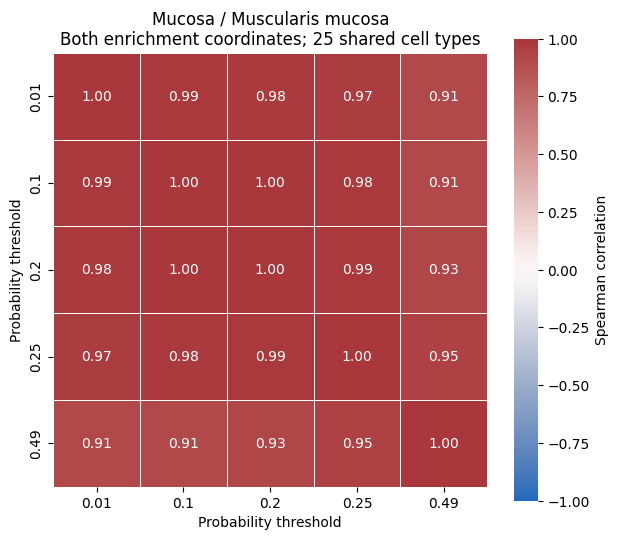

Cell types included:
['B', 'CD4+ T cell', 'CD57+ Enterocyte', 'CD66+ Enterocyte', 'CD7+ Immune', 'CD8+ T', 'Cycling TA', 'DC', 'Endothelial', 'Enterocyte', 'Goblet', 'ICC', 'Lymphatic', 'M1 Macrophage', 'M2 Macrophage', 'MUC1+ Enterocyte', 'NK', 'Nerve', 'Neuroendocrine', 'Neutrophil', 'Paneth', 'Plasma', 'Smooth muscle', 'Stroma', 'TA']


In [22]:
# Reload from CSV so this block also works in later sessions.
enrichment_full = pd.read_csv(
    OUTPUT / "tissue_unit_enrichment_full.csv"
)

selected = []

for threshold in HEATMAP_THRESHOLDS:
    block = enrichment_full.loc[
        np.isclose(
            enrichment_full["threshold"],
            threshold,
            rtol=0,
            atol=1e-10,
        )
    ].copy()

    if block.empty:
        raise ValueError(f"No data for threshold {threshold}.")

    block["threshold"] = threshold
    selected.append(block)

data = pd.concat(selected, ignore_index=True)

# Recalculate eligibility from saved counts.
data["eligible"] = (
    data[["count_cn1_only", "count_border", "count_cn2_only"]]
    .ge(MIN_COUNT)
    .all(axis=1)
    & np.isfinite(
        data[["enrichment_cn1", "enrichment_cn2"]]
    ).all(axis=1)
)

eligibility = data.pivot(
    index="cell_type",
    columns="threshold",
    values="eligible",
).reindex(columns=HEATMAP_THRESHOLDS).fillna(False)

# Same cell types for every comparison.
common_types = eligibility.index[eligibility.all(axis=1)]

if len(common_types) < 2:
    raise ValueError(
        "Fewer than two cell types pass the count filter at every threshold."
    )

profiles = {}

for threshold in HEATMAP_THRESHOLDS:
    table = (
        data.loc[data["threshold"] == threshold]
        .set_index("cell_type")
        .reindex(common_types)
    )

    profiles[threshold] = table[
        ["enrichment_cn1", "enrichment_cn2"]
    ].to_numpy().ravel()

profiles = pd.DataFrame(
    profiles,
    index=pd.MultiIndex.from_product(
        [common_types, ["CN1", "CN2"]],
        names=["cell_type", "reference"],
    ),
)

correlation = profiles.corr(method="spearman")

profiles.to_csv(OUTPUT / "enrichment_coordinate_profiles.csv")
correlation.to_csv(OUTPUT / "enrichment_spearman_correlations.csv")

fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)

ax.set_xlabel("Probability threshold")
ax.set_ylabel("Probability threshold")
ax.set_title(
    f"{N1} / {N2}\n"
    f"Both enrichment coordinates; {len(common_types)} shared cell types"
)

finish_figure(fig, "enrichment_threshold_spearman_heatmap")

print("Cell types included:")
print(common_types.tolist())

In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# OUTPUT should be the updated_threshold_figure folder used earlier.
OUTPUT = Path(OUTPUT)
PLOT_DIR = OUTPUT / "enrichment_distance_heatmaps"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_THRESHOLD = 0.25
PLOT_THRESHOLDS = [0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.33, 0.40, 0.49]
MIN_COUNT = 5  # Use 10 instead if that was your manuscript setting.

data = pd.read_csv(OUTPUT / "tissue_unit_enrichment_full.csv")

if data[["cn1", "cn2"]].drop_duplicates().shape[0] != 1:
    raise ValueError("Select one neighborhood pair before plotting.")

N1 = str(data["cn1"].iloc[0])
N2 = str(data["cn2"].iloc[0])

# Match and standardize threshold values.
blocks = []

for threshold in PLOT_THRESHOLDS:
    block = data.loc[
        np.isclose(
            data["threshold"], threshold,
            atol=1e-10, rtol=0,
        )
    ].copy()

    if block.empty:
        raise ValueError(f"No saved data for threshold {threshold}.")

    block["threshold"] = threshold
    blocks.append(block)

data = pd.concat(blocks, ignore_index=True)

if REFERENCE_THRESHOLD not in PLOT_THRESHOLDS:
    raise ValueError("Include the reference threshold in PLOT_THRESHOLDS.")

if data.duplicated(["cell_type", "threshold"]).any():
    raise ValueError("Duplicate cell-type/threshold rows.")

data["eligible"] = (
    data[["count_cn1_only", "count_border", "count_cn2_only"]]
    .ge(MIN_COUNT)
    .all(axis=1)
    & np.isfinite(
        data[["enrichment_cn1", "enrichment_cn2"]]
    ).all(axis=1)
)

cell_types = sorted(data["cell_type"].unique())

def wide_table(column):
    return data.pivot(
        index="cell_type",
        columns="threshold",
        values=column,
    ).reindex(index=cell_types, columns=PLOT_THRESHOLDS)

x = wide_table("enrichment_cn1")
y = wide_table("enrichment_cn2")
eligible = wide_table("eligible").fillna(False).astype(bool)

def save_figure(fig, name):
    fig.savefig(
        PLOT_DIR / f"{name}.png",
        dpi=300, bbox_inches="tight",
    )
    fig.savefig(
        PLOT_DIR / f"{name}.pdf",
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

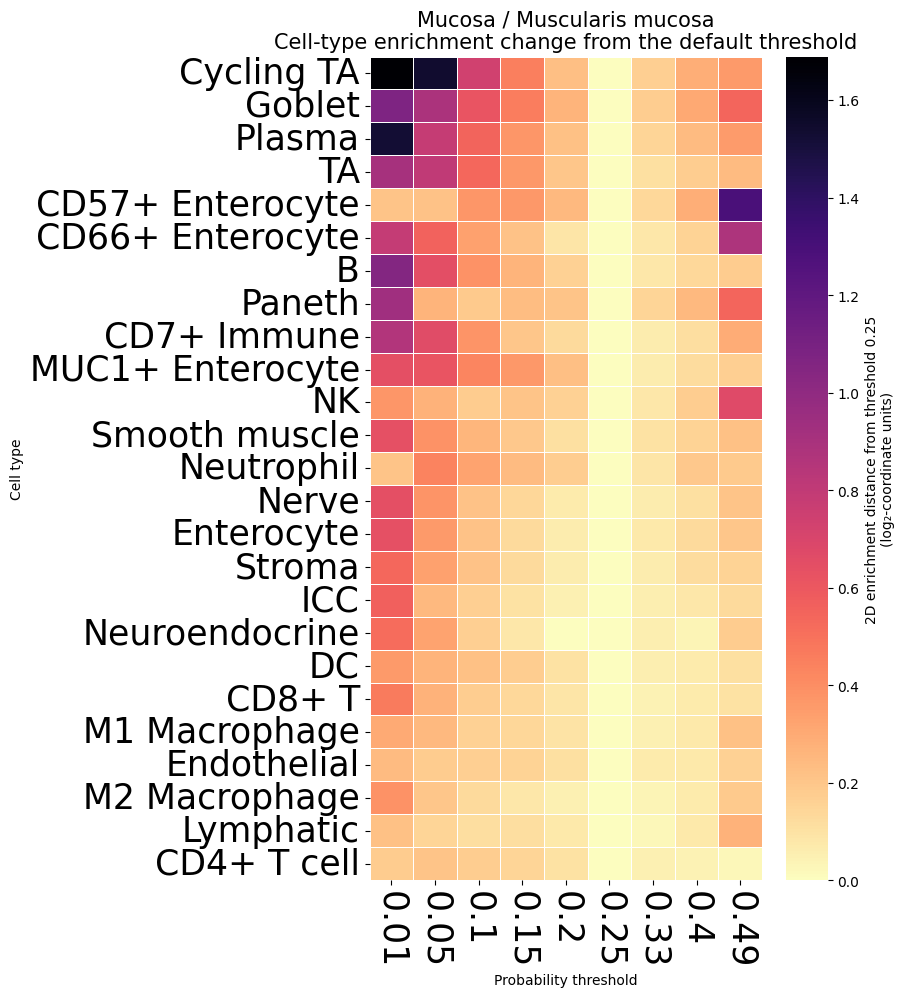

In [45]:
dx = x.sub(x[REFERENCE_THRESHOLD], axis=0)
dy = y.sub(y[REFERENCE_THRESHOLD], axis=0)

distance_from_reference = np.sqrt(dx**2 + dy**2)

valid_comparison = eligible.mul(
    eligible[REFERENCE_THRESHOLD],
    axis=0,
).astype(bool)

distance_from_reference = distance_from_reference.where(valid_comparison)

# Retain cell types with at least one valid nonreference comparison.
nonreference = [
    t for t in PLOT_THRESHOLDS if t != REFERENCE_THRESHOLD
]

keep = distance_from_reference[nonreference].notna().any(axis=1)
distance_from_reference = distance_from_reference.loc[keep]

if distance_from_reference.empty:
    raise ValueError(
        "No cell types have valid reference and nonreference comparisons."
    )

order = (
    distance_from_reference[nonreference]
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

distance_from_reference = distance_from_reference.loc[order]

distance_from_reference.to_csv(
    PLOT_DIR / "cell_type_distance_from_reference.csv"
)

# Also retain signed changes so direction can be inspected later.
dx.where(valid_comparison).to_csv(
    PLOT_DIR / "change_in_cn1_enrichment_from_reference.csv"
)
dy.where(valid_comparison).to_csv(
    PLOT_DIR / "change_in_cn2_enrichment_from_reference.csv"
)

fig, ax = plt.subplots(
    figsize=(11, max(5, 0.34 * len(order) + 2))
)
ax.set_facecolor("#e6e6e6")

vmax = max(float(distance_from_reference.max().max()), 0.01)

sns.heatmap(
    distance_from_reference,
    mask=distance_from_reference.isna(),
    cmap="magma_r",
    vmin=0,
    vmax=vmax,
    annot=False,
    fmt=".2f",
    annot_kws={"fontsize": 8},
    linewidths=0.4,
    linecolor="white",
    cbar_kws={
        "label": "2D enrichment distance from threshold 0.25\n"
                 "(log₂-coordinate units)"
    },
    ax=ax,
)

ax.set_title(
    f"{N1} / {N2}\n"
    "Cell-type enrichment change from the default threshold",
    fontsize=15,
)
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Cell type")
ax.set_xticklabels([f"{t:g}" for t in PLOT_THRESHOLDS], rotation=0)
ax.tick_params(axis="y", labelsize=25, rotation=0)
ax.tick_params(axis="x", labelsize=25, rotation=270)


fig.tight_layout(rect=(0, 0.04, 0.8, 1))
save_figure(fig, "cell_type_enrichment_distance_from_025")

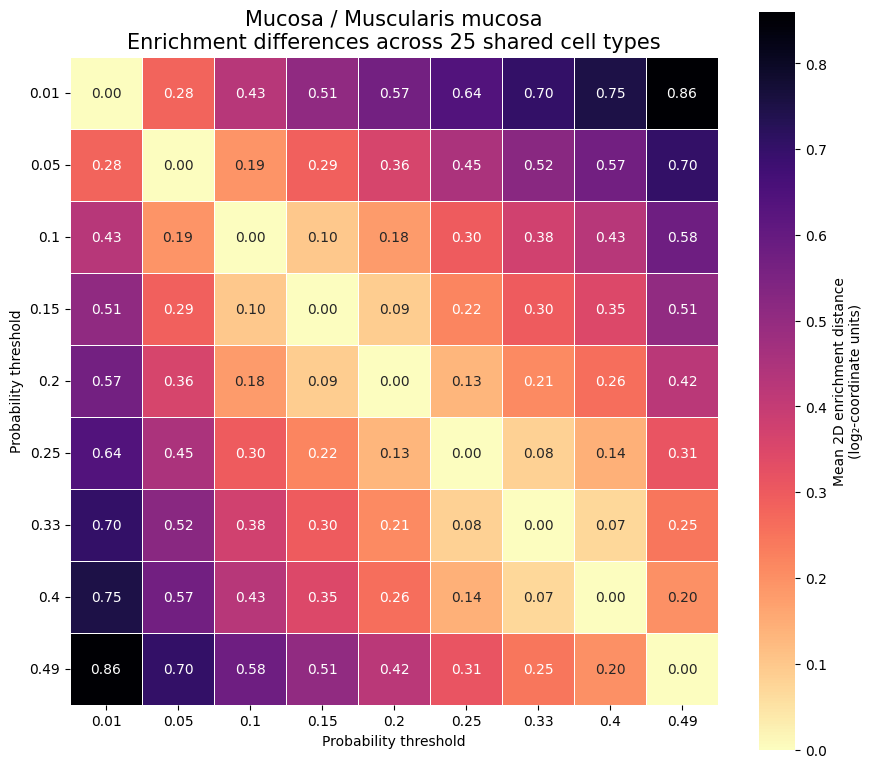

Shared cell types (25):
B, CD4+ T cell, CD57+ Enterocyte, CD66+ Enterocyte, CD7+ Immune, CD8+ T, Cycling TA, DC, Endothelial, Enterocyte, Goblet, ICC, Lymphatic, M1 Macrophage, M2 Macrophage, MUC1+ Enterocyte, NK, Nerve, Neuroendocrine, Neutrophil, Paneth, Plasma, Smooth muscle, Stroma, TA

Saved figures and numerical tables to: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure\enrichment_distance_heatmaps


In [26]:
common_types = eligible.index[eligible.all(axis=1)]

if len(common_types) == 0:
    raise ValueError(
        "No cell types pass the count filter at every threshold. "
        "Consider displaying a narrower threshold range."
    )

# Shape: cell types × thresholds × two enrichment coordinates.
coordinates = np.stack(
    [
        x.loc[common_types].to_numpy(dtype=float),
        y.loc[common_types].to_numpy(dtype=float),
    ],
    axis=-1,
)

n_thresholds = len(PLOT_THRESHOLDS)
mean_distances = np.zeros((n_thresholds, n_thresholds))
individual_distances = []

for i, threshold_a in enumerate(PLOT_THRESHOLDS):
    for j in range(i, n_thresholds):
        threshold_b = PLOT_THRESHOLDS[j]

        distances = np.linalg.norm(
            coordinates[:, i, :] - coordinates[:, j, :],
            axis=1,
        )

        mean_distances[i, j] = distances.mean()
        mean_distances[j, i] = distances.mean()

        individual_distances.append(pd.DataFrame({
            "cell_type": common_types,
            "threshold_a": threshold_a,
            "threshold_b": threshold_b,
            "distance": distances,
        }))

mean_distance_table = pd.DataFrame(
    mean_distances,
    index=pd.Index(PLOT_THRESHOLDS, name="threshold"),
    columns=PLOT_THRESHOLDS,
)

mean_distance_table.to_csv(
    PLOT_DIR / "mean_pairwise_enrichment_distance.csv"
)

pd.concat(individual_distances, ignore_index=True).to_csv(
    PLOT_DIR / "pairwise_enrichment_distance_by_cell_type.csv",
    index=False,
)

pd.Series(common_types, name="cell_type").to_csv(
    PLOT_DIR / "shared_cell_types.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(9, 8))

sns.heatmap(
    mean_distance_table,
    cmap="magma_r",
    vmin=0,
    vmax=max(float(mean_distances.max()), 0.01),
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={
        "label": "Mean 2D enrichment distance\n(log₂-coordinate units)"
    },
    ax=ax,
)

labels = [f"{t:g}" for t in PLOT_THRESHOLDS]
ax.set_xticklabels(labels, rotation=0)
ax.set_yticklabels(labels, rotation=0)

ax.set_xlabel("Probability threshold")
ax.set_ylabel("Probability threshold")
ax.set_title(
    f"{N1} / {N2}\n"
    f"Enrichment differences across {len(common_types)} shared cell types",
    fontsize=15,
)

fig.tight_layout()
save_figure(fig, "threshold_pairwise_enrichment_distance")

print(f"Shared cell types ({len(common_types)}):")
print(", ".join(common_types))
print("\nSaved figures and numerical tables to:", PLOT_DIR)

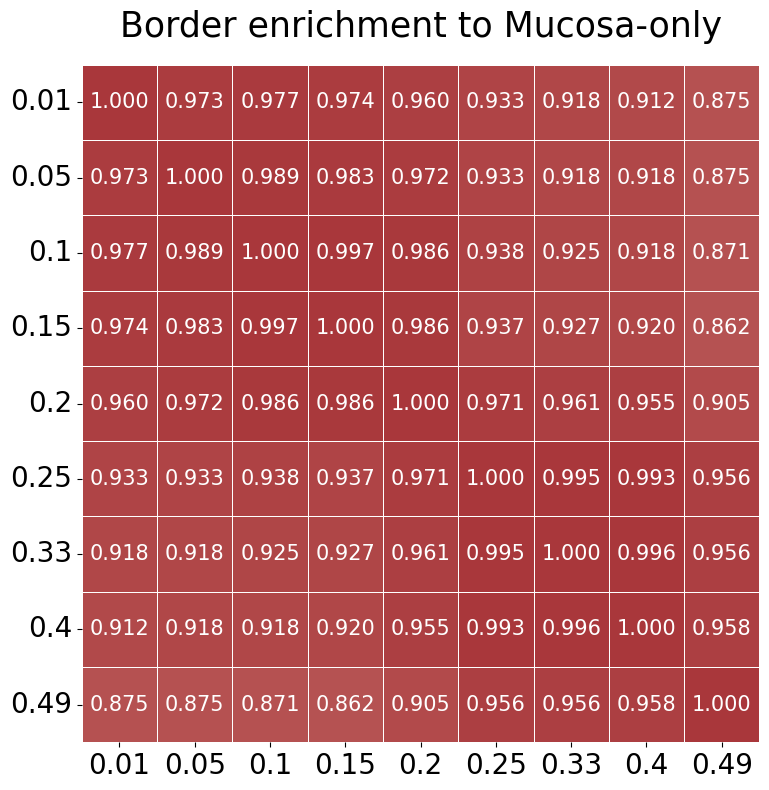

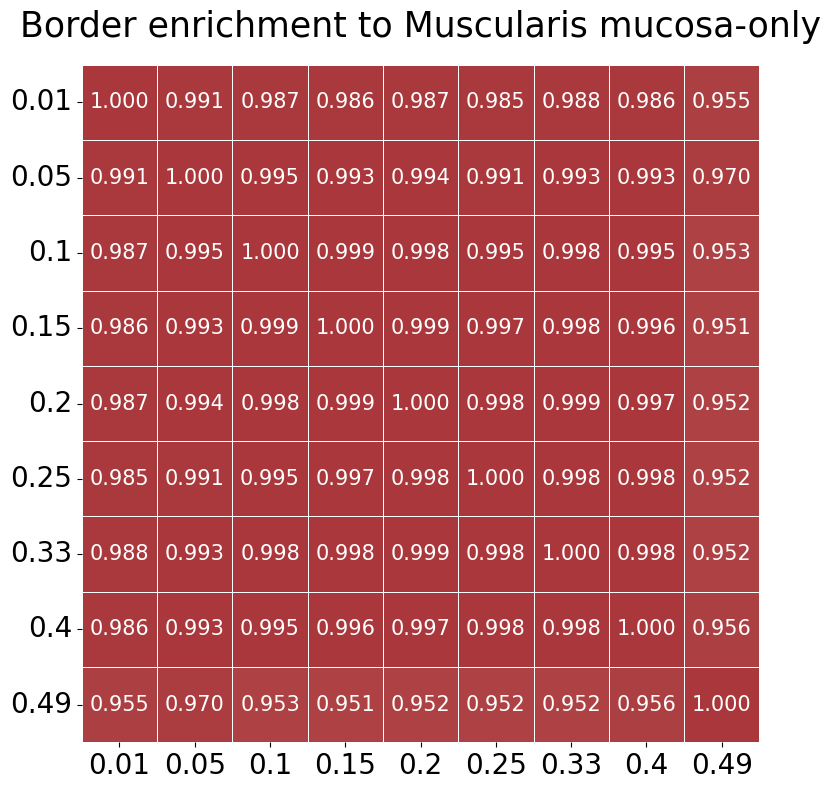

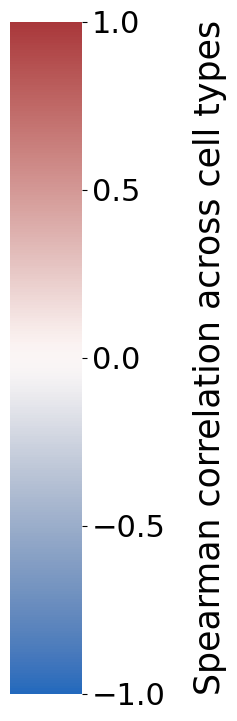

In [37]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

common_types = eligible.index[eligible.all(axis=1)]

if len(common_types) < 3:
    raise ValueError("Need at least three shared eligible cell types.")

COLOR_MIN = -1
COLOR_MAX = 1

# Identical color mapping for both heatmaps and the separate legend.
cmap = sns.color_palette("vlag", as_cmap=True)
norm = Normalize(vmin=COLOR_MIN, vmax=COLOR_MAX)

correlation_tables = {}

for reference, neighborhood, coordinates in [
    ("CN1", N1, x),
    ("CN2", N2, y),
]:
    values = coordinates.loc[common_types, PLOT_THRESHOLDS]

    if not np.isfinite(values.to_numpy()).all():
        raise ValueError(f"{reference}: nonfinite enrichment values.")

    constant = values.nunique() < 2
    if constant.any():
        raise ValueError(
            f"{reference}: correlation is undefined for constant profiles "
            f"at thresholds {constant.index[constant].tolist()}."
        )

    correlation = values.corr(method="spearman")
    correlation_tables[reference] = correlation

    correlation.to_csv(
        PLOT_DIR / f"spearman_enrichment_{reference}.csv"
    )

    fig, ax = plt.subplots(figsize=(9, 8))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".3f",
        annot_kws={"fontsize": 15},
        cmap=cmap,
        vmin=COLOR_MIN,
        vmax=COLOR_MAX,
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )

    labels = [f"{t:g}" for t in PLOT_THRESHOLDS]
    ax.set_xticklabels(labels, rotation=0, fontsize=20)
    ax.set_yticklabels(labels, rotation=0, fontsize=20)

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_title(
    f"Border enrichment to {neighborhood}-only",
    fontsize=25,
    pad=20,
    )

    fig.tight_layout()
    save_figure(fig, f"enrichment_spearman_{reference}")

# Separate color-bar figure shared by both heatmaps.
fig_legend = plt.figure(figsize=(4, 8))
cax = fig_legend.add_axes([0.15, 0.08, 0.18, 0.84])

colorbar = fig_legend.colorbar(
    ScalarMappable(norm=norm, cmap=cmap),
    cax=cax,
    orientation="vertical",
    ticks=np.linspace(COLOR_MIN, COLOR_MAX, 5),
)

colorbar.ax.tick_params(labelsize=22)
colorbar.set_label(
    "Spearman correlation across cell types",
    fontsize=25,
    labelpad=20,
)
colorbar.outline.set_visible(False)

save_figure(fig_legend, "enrichment_spearman_colorbar")

Loaded: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure\tissue_unit_enrichment_full.csv
Rows: 225
Available thresholds:
[0.01 0.05 0.1  0.15 0.2  0.25 0.33 0.4  0.49]
Shared eligible cell types: 24
['B', 'CD4+ T cell', 'CD66+ Enterocyte', 'CD7+ Immune', 'CD8+ T', 'Cycling TA', 'DC', 'Endothelial', 'Enterocyte', 'Goblet', 'ICC', 'Lymphatic', 'M1 Macrophage', 'M2 Macrophage', 'MUC1+ Enterocyte', 'NK', 'Nerve', 'Neuroendocrine', 'Neutrophil', 'Paneth', 'Plasma', 'Smooth muscle', 'Stroma', 'TA']
Saved: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure\spearman_heatmaps\spearman_enrichment_CN1.csv
Saved: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure\spearman_heatmaps\spearman_enrichment_CN2.csv
Lowest off-diagonal correlation: 0.8913
Shared color scale: 0.89 to 1.00
Saved: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_th

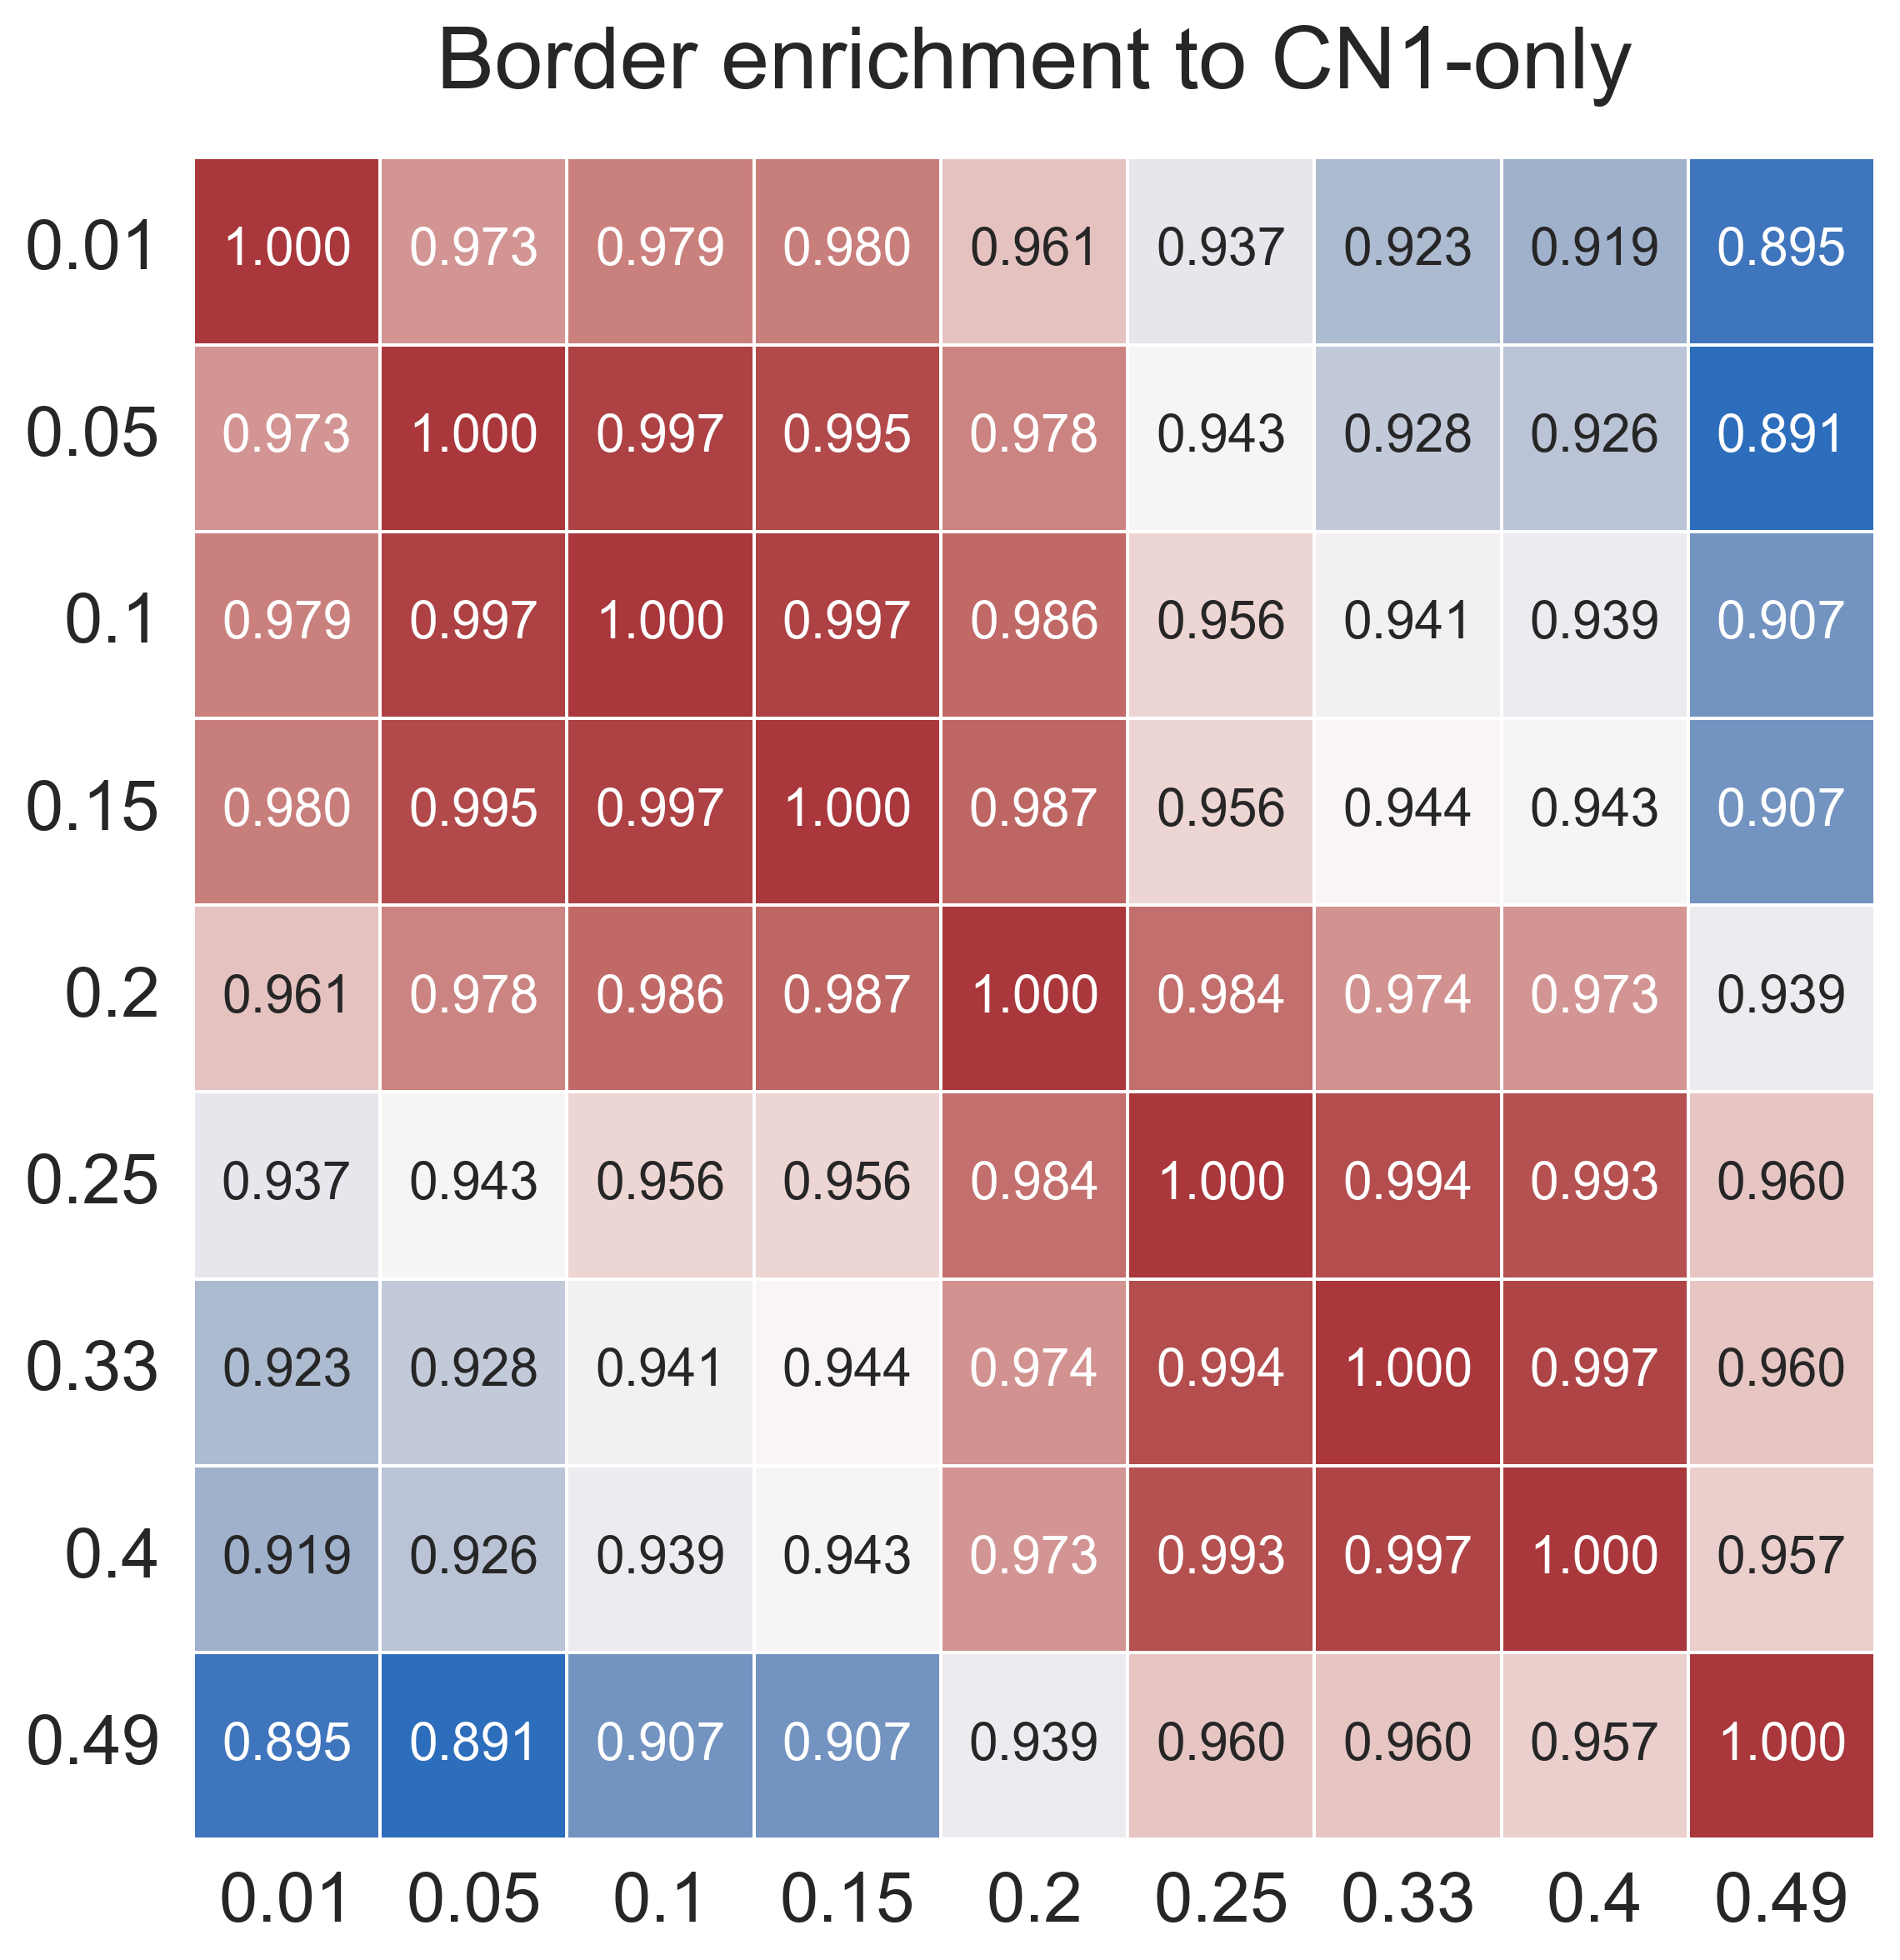

Saved: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure\spearman_heatmaps\enrichment_spearman_CN2.png
Saved: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure\spearman_heatmaps\enrichment_spearman_CN2.pdf


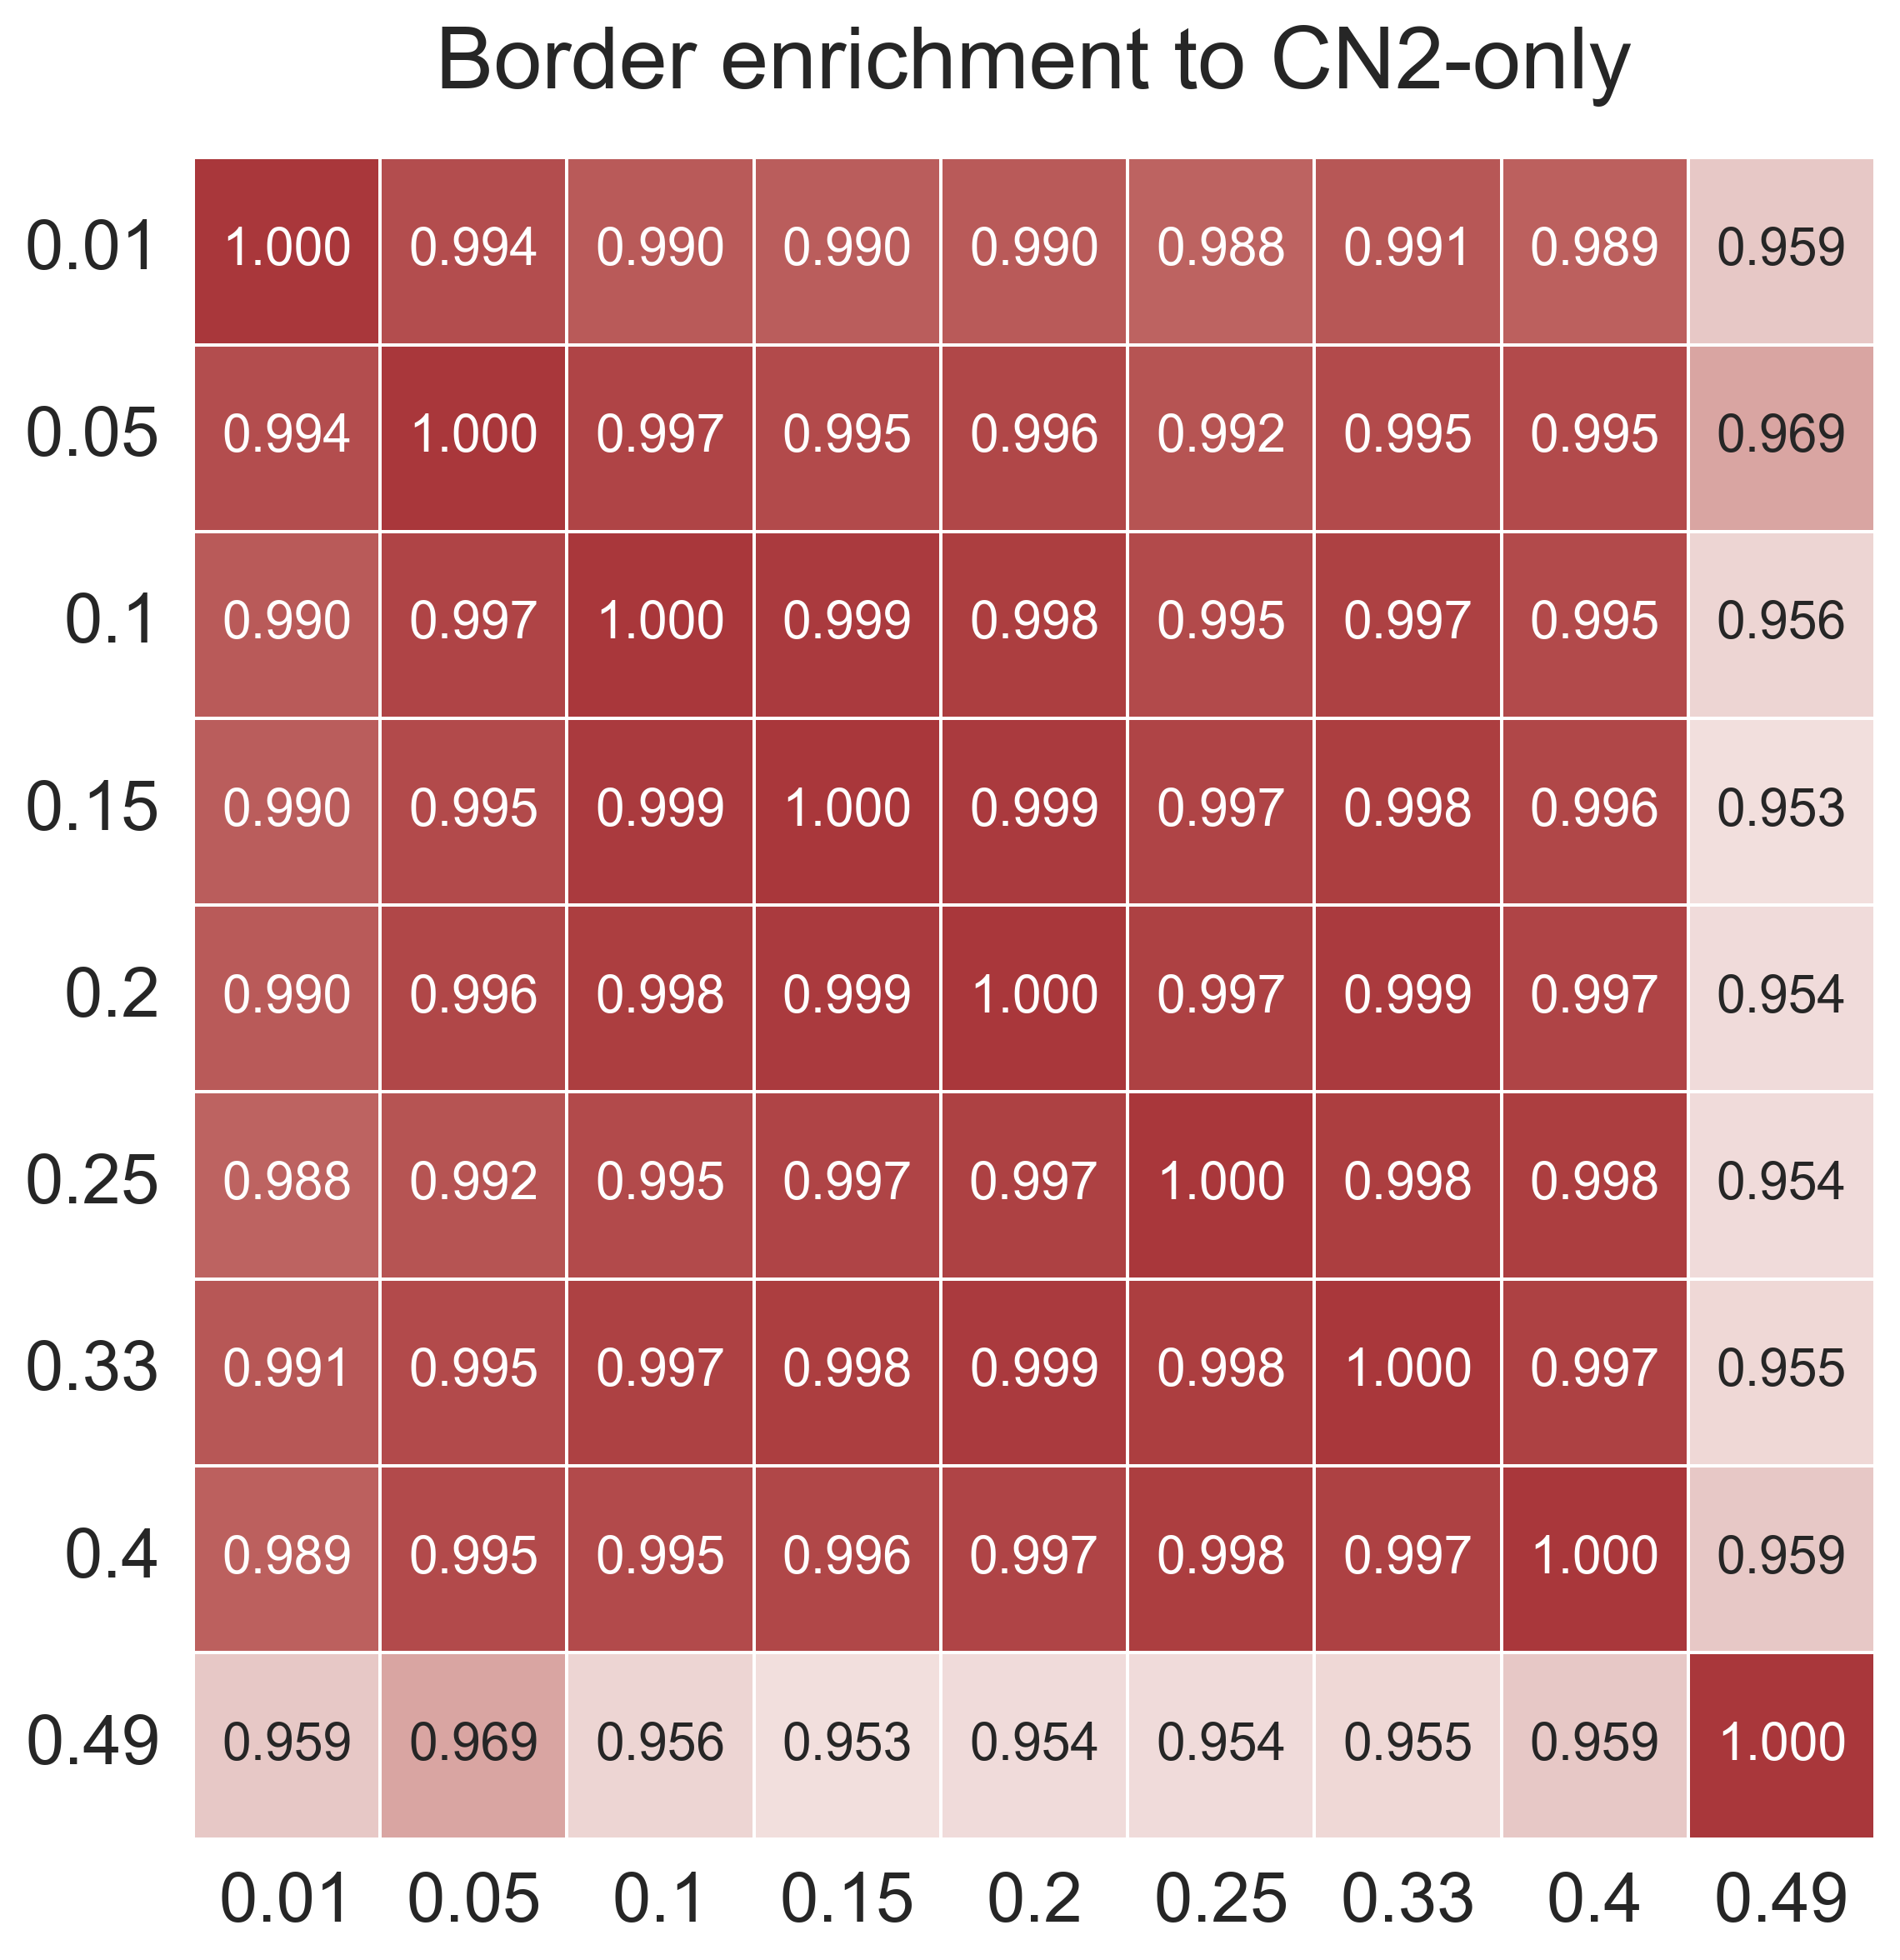

Saved: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure\spearman_heatmaps\enrichment_spearman_colorbar.png
Saved: C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure\spearman_heatmaps\enrichment_spearman_colorbar.pdf


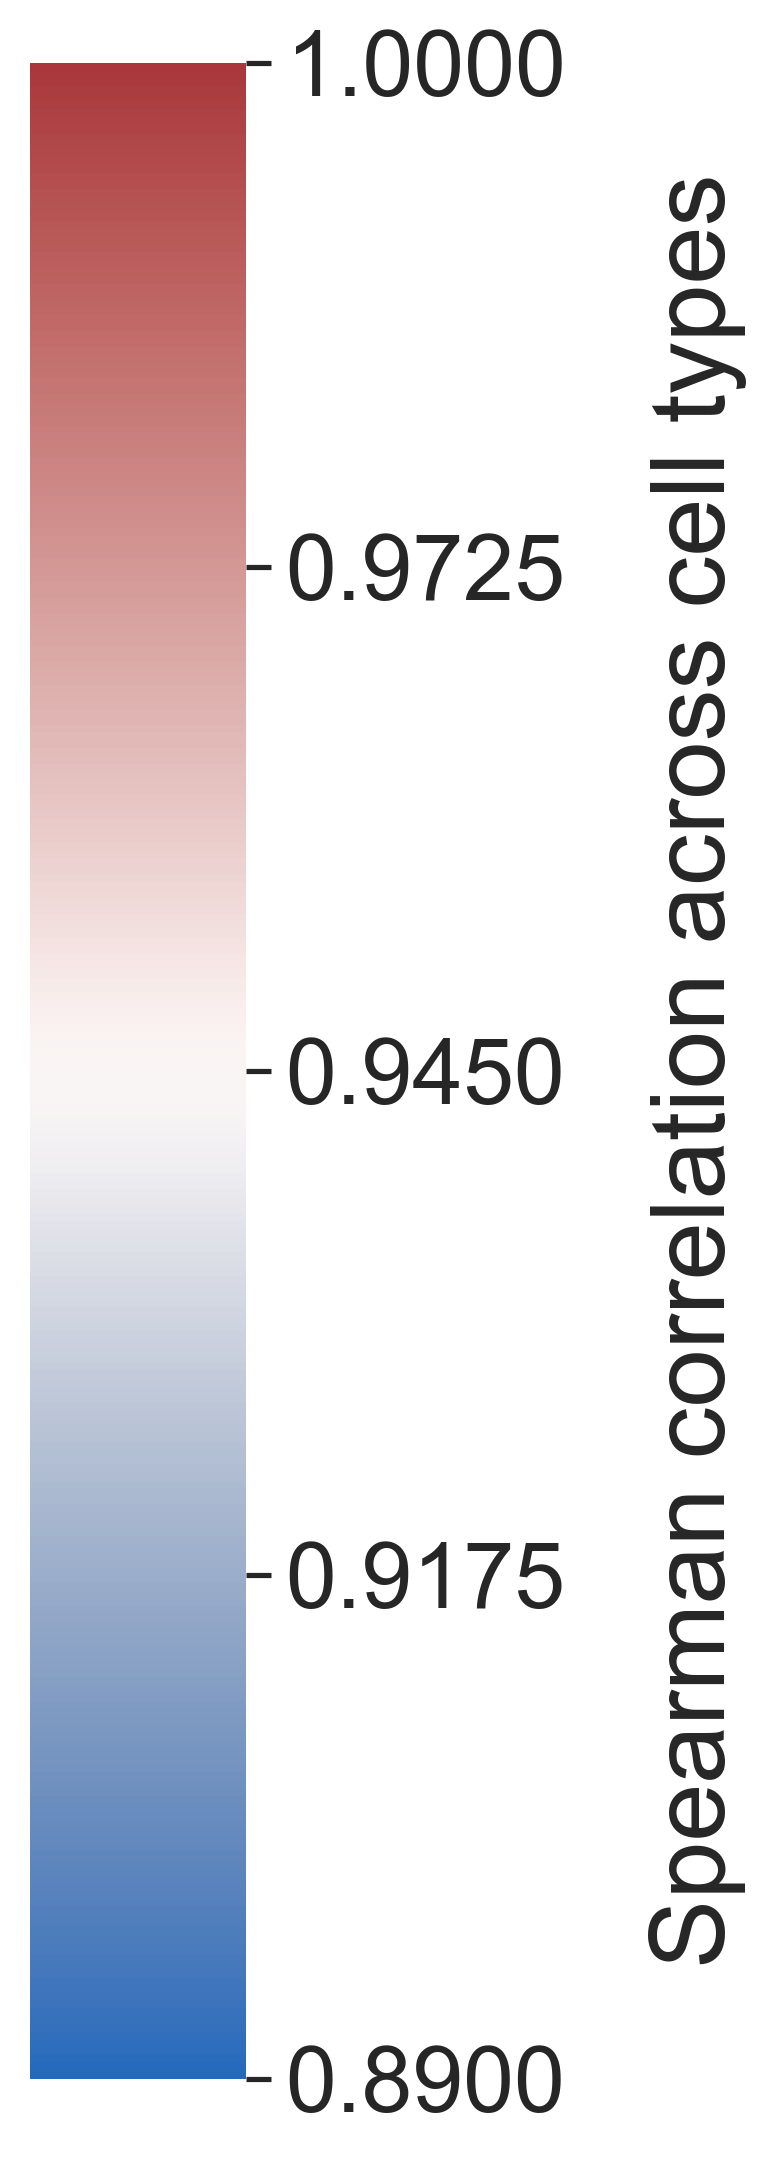

In [15]:
# ================================================================
# STANDALONE CN1/CN2 SPEARMAN CORRELATION HEATMAPS
# ================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ----------------------------------------------------------------
# SETTINGS
# ----------------------------------------------------------------

# Change this to the folder containing:
# tissue_unit_enrichment_full.csv
OUTPUT = Path(
    r"C:\Users\k1van\Mingl\border_figures\outputs\figure2_threshold_effects\updated_threshold_figure"
)

INPUT_FILE = OUTPUT / "tissue_unit_enrichment_full.csv"

# Figures will be saved here
PLOT_DIR = OUTPUT / "spearman_heatmaps"
PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Minimum required number of cells in each group
MIN_COUNT = 20

# Set to None to use every threshold available in the CSV.
# Alternatively, supply specific thresholds, for example:
# PLOT_THRESHOLDS = [0.05, 0.15, 0.25, 0.35, 0.45]
PLOT_THRESHOLDS = None

# Names displayed in the heatmap titles
N1 = "CN1"
N2 = "CN2"


# ----------------------------------------------------------------
# FIGURE-SAVING FUNCTION
# ----------------------------------------------------------------

def save_figure(
    fig,
    filename,
    output_dir=PLOT_DIR,
    dpi=300,
):
    png_path = output_dir / f"{filename}.png"
    pdf_path = output_dir / f"{filename}.pdf"

    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


# ----------------------------------------------------------------
# READ THE SAVED ENRICHMENT TABLE
# ----------------------------------------------------------------

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Could not find the required input file:\n{INPUT_FILE}"
    )

enrichment_full = pd.read_csv(
    INPUT_FILE
)

required_columns = [
    "threshold",
    "cell_type",
    "count_cn1_only",
    "count_border",
    "count_cn2_only",
    "enrichment_cn1",
    "enrichment_cn2",
]

missing_columns = [
    column for column in required_columns
    if column not in enrichment_full.columns
]

if missing_columns:
    raise KeyError(
        "The input file is missing required columns: "
        f"{missing_columns}"
    )

numeric_columns = [
    "threshold",
    "count_cn1_only",
    "count_border",
    "count_cn2_only",
    "enrichment_cn1",
    "enrichment_cn2",
]

for column in numeric_columns:
    enrichment_full[column] = pd.to_numeric(
        enrichment_full[column],
        errors="coerce",
    )

if enrichment_full["threshold"].isna().all():
    raise ValueError(
        "The threshold column contains no valid numeric values."
    )

print(f"Loaded: {INPUT_FILE}")
print(f"Rows: {len(enrichment_full):,}")


# ----------------------------------------------------------------
# SELECT THRESHOLDS
# ----------------------------------------------------------------

available_thresholds = np.sort(
    enrichment_full["threshold"]
    .dropna()
    .unique()
)

print("Available thresholds:")
print(available_thresholds)

if PLOT_THRESHOLDS is None:
    PLOT_THRESHOLDS = available_thresholds
else:
    PLOT_THRESHOLDS = np.asarray(
        PLOT_THRESHOLDS,
        dtype=float,
    )

if len(PLOT_THRESHOLDS) < 2:
    raise ValueError(
        "At least two thresholds are required to calculate "
        "a correlation matrix."
    )

selected_blocks = []

for threshold in PLOT_THRESHOLDS:
    block = enrichment_full.loc[
        np.isclose(
            enrichment_full["threshold"],
            threshold,
            rtol=0,
            atol=1e-10,
        )
    ].copy()

    if block.empty:
        raise ValueError(
            f"No data were found for threshold {threshold:g}."
        )

    # Standardize floating-point threshold values
    block["threshold"] = float(threshold)
    selected_blocks.append(block)

data = pd.concat(
    selected_blocks,
    ignore_index=True,
)


# ----------------------------------------------------------------
# VALIDATE UNIQUE CELL-TYPE/THRESHOLD COMBINATIONS
# ----------------------------------------------------------------

duplicate_rows = data.duplicated(
    subset=[
        "cell_type",
        "threshold",
    ],
    keep=False,
)

if duplicate_rows.any():
    duplicate_examples = (
        data.loc[
            duplicate_rows,
            ["cell_type", "threshold"],
        ]
        .drop_duplicates()
        .head(10)
    )

    raise ValueError(
        "Multiple rows were found for the same cell type and "
        "threshold. Example duplicates:\n"
        f"{duplicate_examples}"
    )


# ----------------------------------------------------------------
# RECONSTRUCT ELIGIBILITY
# ----------------------------------------------------------------

count_columns = [
    "count_cn1_only",
    "count_border",
    "count_cn2_only",
]

enrichment_columns = [
    "enrichment_cn1",
    "enrichment_cn2",
]

data["eligible"] = (
    data[count_columns]
    .ge(MIN_COUNT)
    .all(axis=1)
    &
    np.isfinite(
        data[enrichment_columns]
        .to_numpy(dtype=float)
    ).all(axis=1)
)

eligible = (
    data.pivot(
        index="cell_type",
        columns="threshold",
        values="eligible",
    )
    .reindex(columns=PLOT_THRESHOLDS)
    .fillna(False)
    .astype(bool)
)

# Retain the same cell types at every plotted threshold
common_types = eligible.index[
    eligible.all(axis=1)
]

if len(common_types) < 3:
    raise ValueError(
        "Need at least three cell types that are eligible at "
        "every selected threshold."
    )

print(
    f"Shared eligible cell types: {len(common_types)}"
)
print(common_types.tolist())


# ----------------------------------------------------------------
# RECONSTRUCT CN1 AND CN2 ENRICHMENT MATRICES
# ----------------------------------------------------------------

x = (
    data.pivot(
        index="cell_type",
        columns="threshold",
        values="enrichment_cn1",
    )
    .reindex(
        index=common_types,
        columns=PLOT_THRESHOLDS,
    )
)

y = (
    data.pivot(
        index="cell_type",
        columns="threshold",
        values="enrichment_cn2",
    )
    .reindex(
        index=common_types,
        columns=PLOT_THRESHOLDS,
    )
)

if not np.isfinite(x.to_numpy(dtype=float)).all():
    raise ValueError(
        "CN1 contains nonfinite enrichment values after filtering."
    )

if not np.isfinite(y.to_numpy(dtype=float)).all():
    raise ValueError(
        "CN2 contains nonfinite enrichment values after filtering."
    )


# ----------------------------------------------------------------
# CALCULATE BOTH CORRELATION MATRICES
# ----------------------------------------------------------------

correlation_tables = {}

for reference, neighborhood, coordinates in [
    ("CN1", N1, x),
    ("CN2", N2, y),
]:
    values = coordinates.loc[
        common_types,
        PLOT_THRESHOLDS,
    ]

    if not np.isfinite(values.to_numpy()).all():
        raise ValueError(
            f"{reference}: nonfinite enrichment values."
        )

    constant = values.nunique(axis=0) < 2

    if constant.any():
        raise ValueError(
            f"{reference}: correlation is undefined for constant "
            "profiles at thresholds "
            f"{constant.index[constant].tolist()}."
        )

    correlation = values.corr(
        method="spearman"
    )

    if correlation.isna().any().any():
        raise ValueError(
            f"{reference}: the correlation matrix contains "
            "missing values."
        )

    correlation_tables[reference] = correlation

    correlation_file = (
        PLOT_DIR
        / f"spearman_enrichment_{reference}.csv"
    )

    correlation.to_csv(
        correlation_file
    )

    print(f"Saved: {correlation_file}")


# ----------------------------------------------------------------
# DETERMINE ONE SHARED COLOR SCALE
# ----------------------------------------------------------------

off_diagonal_values = []

for correlation in correlation_tables.values():
    correlation_array = correlation.to_numpy(
        dtype=float
    )

    off_diagonal_mask = ~np.eye(
        correlation_array.shape[0],
        dtype=bool,
    )

    finite_off_diagonal = correlation_array[
        off_diagonal_mask
    ]

    finite_off_diagonal = finite_off_diagonal[
        np.isfinite(finite_off_diagonal)
    ]

    off_diagonal_values.append(
        finite_off_diagonal
    )

off_diagonal_values = np.concatenate(
    off_diagonal_values
)

if len(off_diagonal_values) == 0:
    raise ValueError(
        "No finite off-diagonal correlations are available."
    )

lowest_correlation = np.min(
    off_diagonal_values
)

# Round downward to the nearest hundredth
COLOR_MIN = (
    np.floor(lowest_correlation * 100)
    / 100
)

COLOR_MAX = 1.0

# Respect the valid Spearman range
COLOR_MIN = max(
    -1.0,
    COLOR_MIN,
)

# Avoid a zero-width scale
if np.isclose(COLOR_MIN, COLOR_MAX):
    COLOR_MIN = COLOR_MAX - 0.01

print(
    f"Lowest off-diagonal correlation: "
    f"{lowest_correlation:.4f}"
)

print(
    f"Shared color scale: "
    f"{COLOR_MIN:.2f} to {COLOR_MAX:.2f}"
)


# ----------------------------------------------------------------
# IDENTICAL COLOR MAPPING FOR BOTH HEATMAPS
# ----------------------------------------------------------------

cmap = sns.color_palette(
    "vlag",
    as_cmap=True,
)

norm = Normalize(
    vmin=COLOR_MIN,
    vmax=COLOR_MAX,
)


# ----------------------------------------------------------------
# PLOT CN1 AND CN2 HEATMAPS
# ----------------------------------------------------------------

sns.set_theme(
    style="white",
)

threshold_labels = [
    f"{threshold:g}"
    for threshold in PLOT_THRESHOLDS
]

for reference, neighborhood, coordinates in [
    ("CN1", N1, x),
    ("CN2", N2, y),
]:
    correlation = correlation_tables[
        reference
    ]

    fig, ax = plt.subplots(
        figsize=(9, 8),
        dpi=300,
    )

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".3f",
        annot_kws={
            "fontsize": 15,
        },
        cmap=cmap,
        vmin=COLOR_MIN,
        vmax=COLOR_MAX,
        cbar=False,
        square=True,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )

    ax.set_xticklabels(
        threshold_labels,
        rotation=0,
        fontsize=20,
    )

    ax.set_yticklabels(
        threshold_labels,
        rotation=0,
        fontsize=20,
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.set_title(
        f"Border enrichment to {neighborhood}-only",
        fontsize=25,
        pad=20,
    )

    fig.tight_layout()

    save_figure(
        fig,
        f"enrichment_spearman_{reference}",
    )

    plt.show()


# ----------------------------------------------------------------
# SEPARATE SHARED COLOR-BAR FIGURE
# ----------------------------------------------------------------

fig_legend = plt.figure(
    figsize=(4, 8),
    dpi=300,
)

cax = fig_legend.add_axes(
    [0.15, 0.08, 0.18, 0.84]
)

colorbar = fig_legend.colorbar(
    ScalarMappable(
        norm=norm,
        cmap=cmap,
    ),
    cax=cax,
    orientation="vertical",
    ticks=np.linspace(
        COLOR_MIN,
        COLOR_MAX,
        5,
    ),
)

colorbar.ax.tick_params(
    labelsize=22
)

colorbar.set_label(
    "Spearman correlation across cell types",
    fontsize=25,
    labelpad=20,
)

colorbar.outline.set_visible(False)

save_figure(
    fig_legend,
    "enrichment_spearman_colorbar",
)

plt.show()

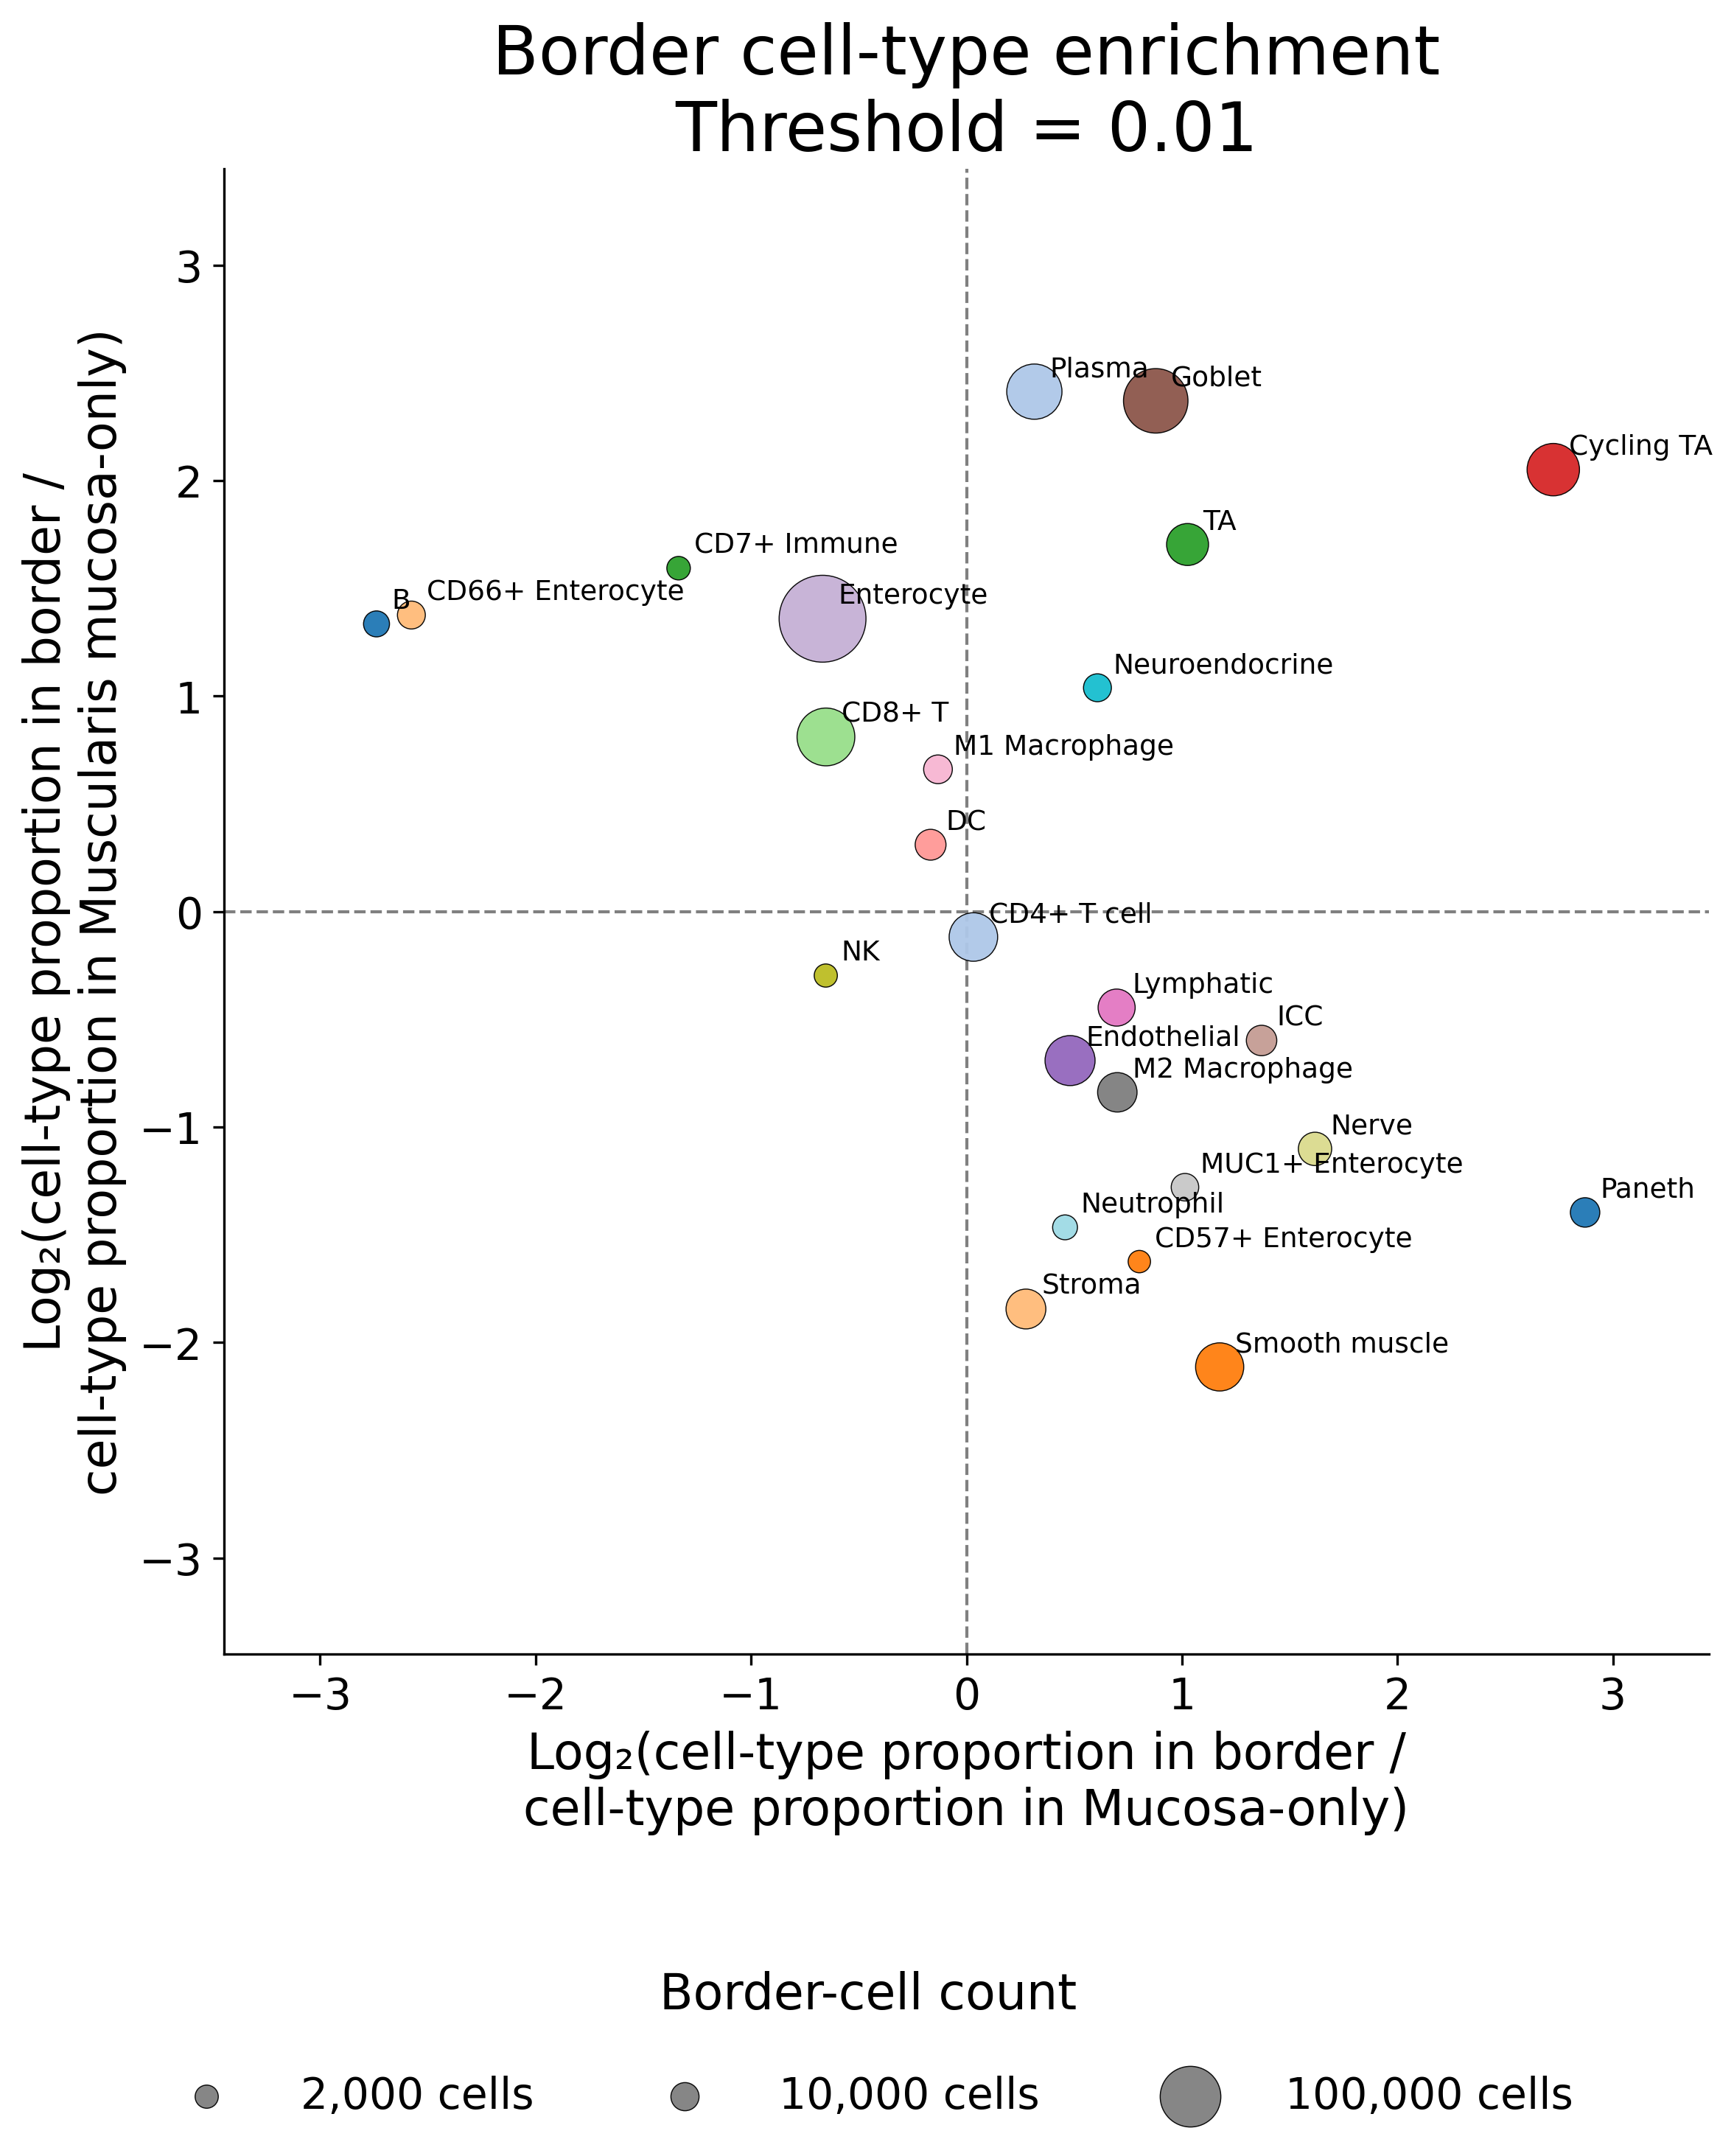

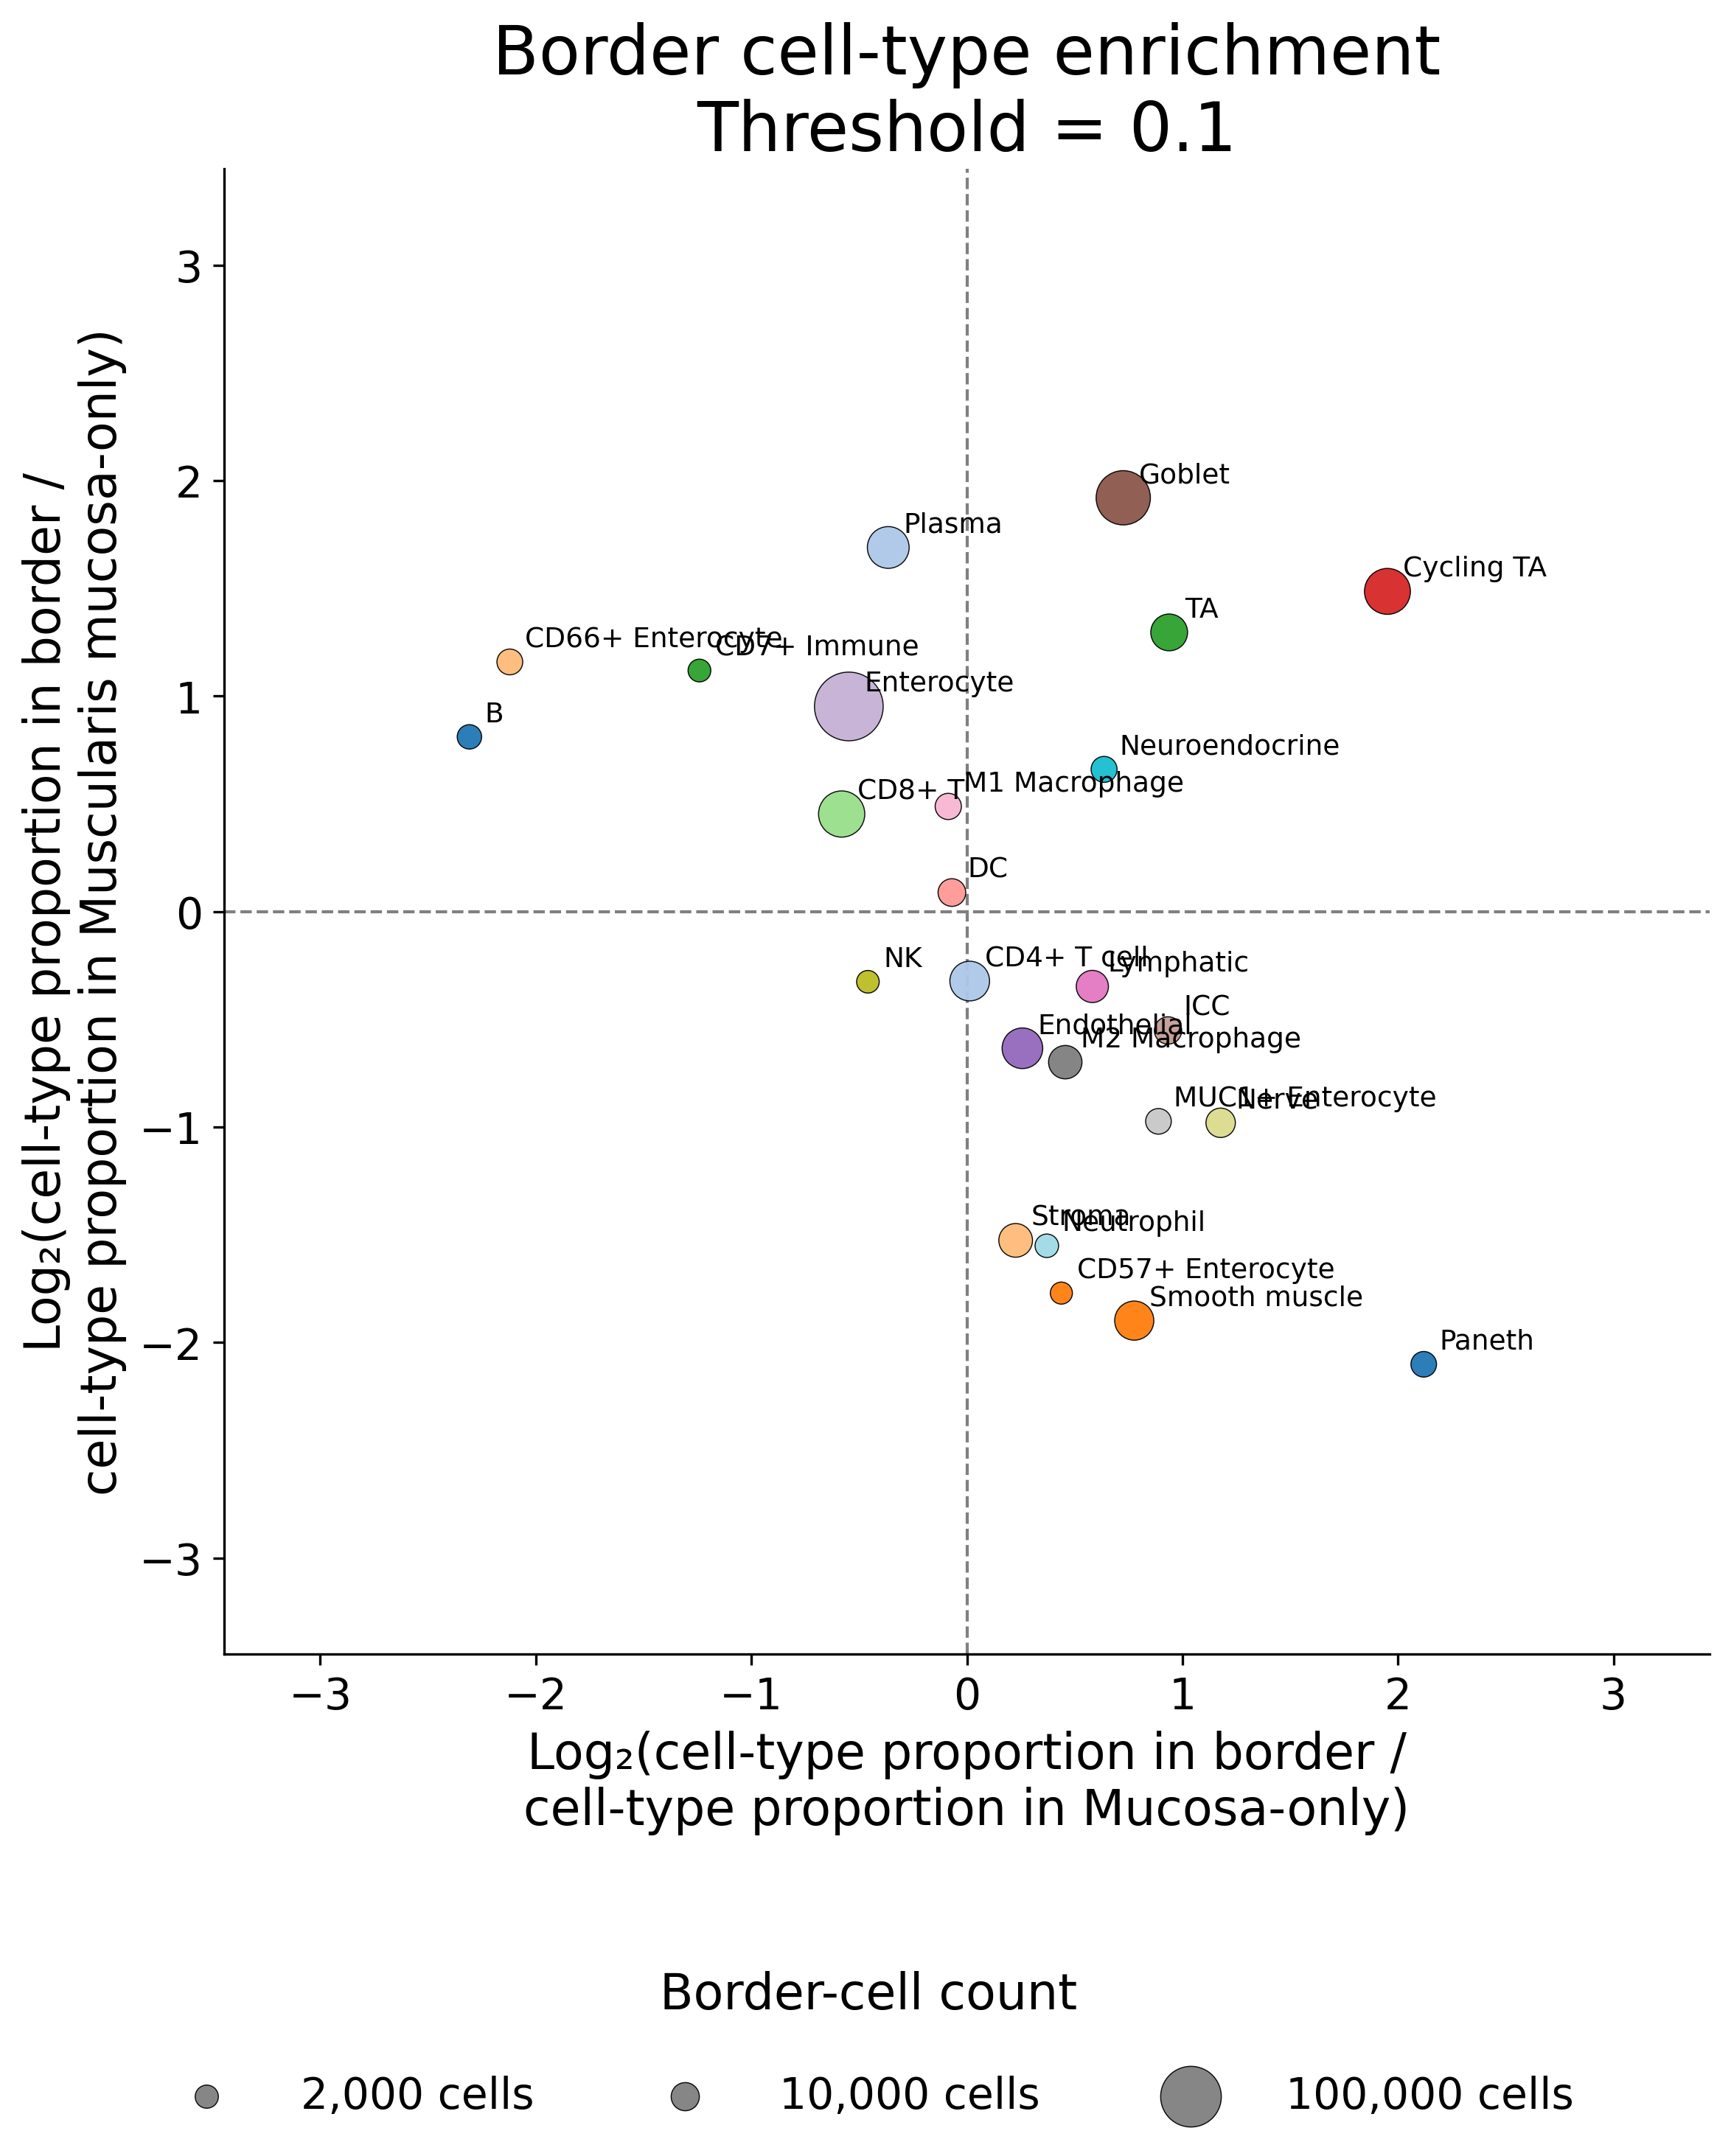

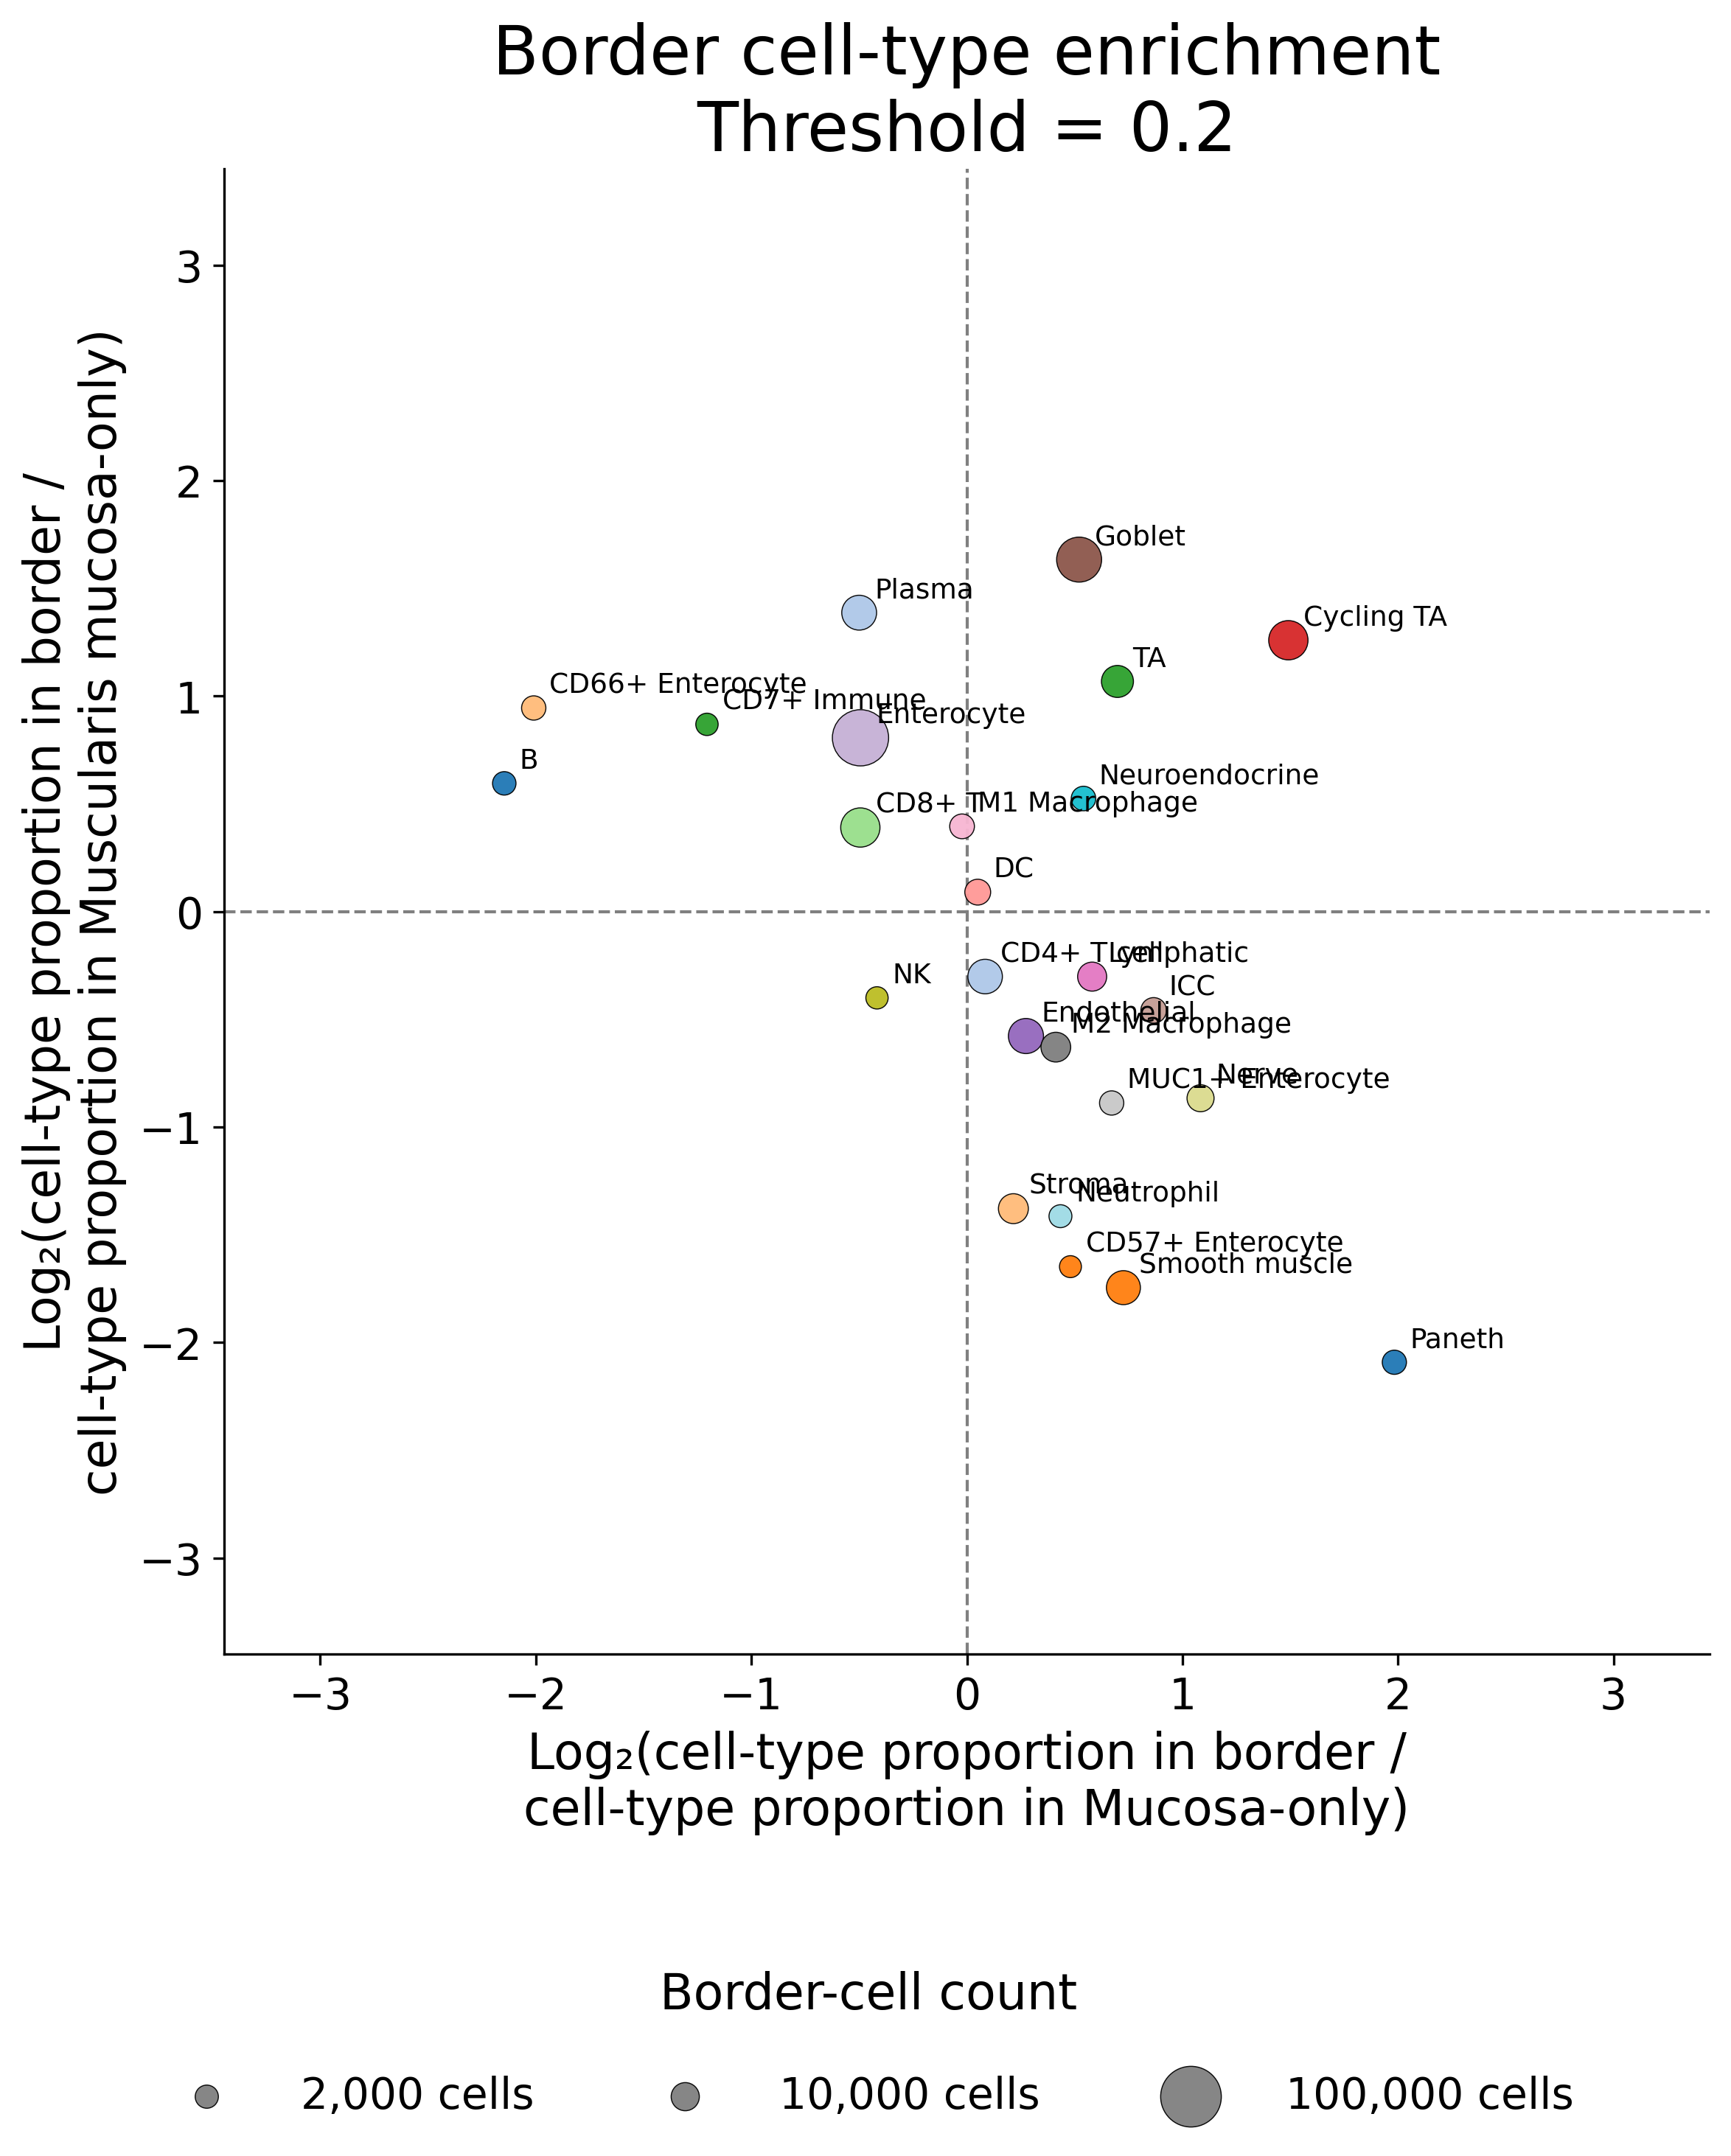

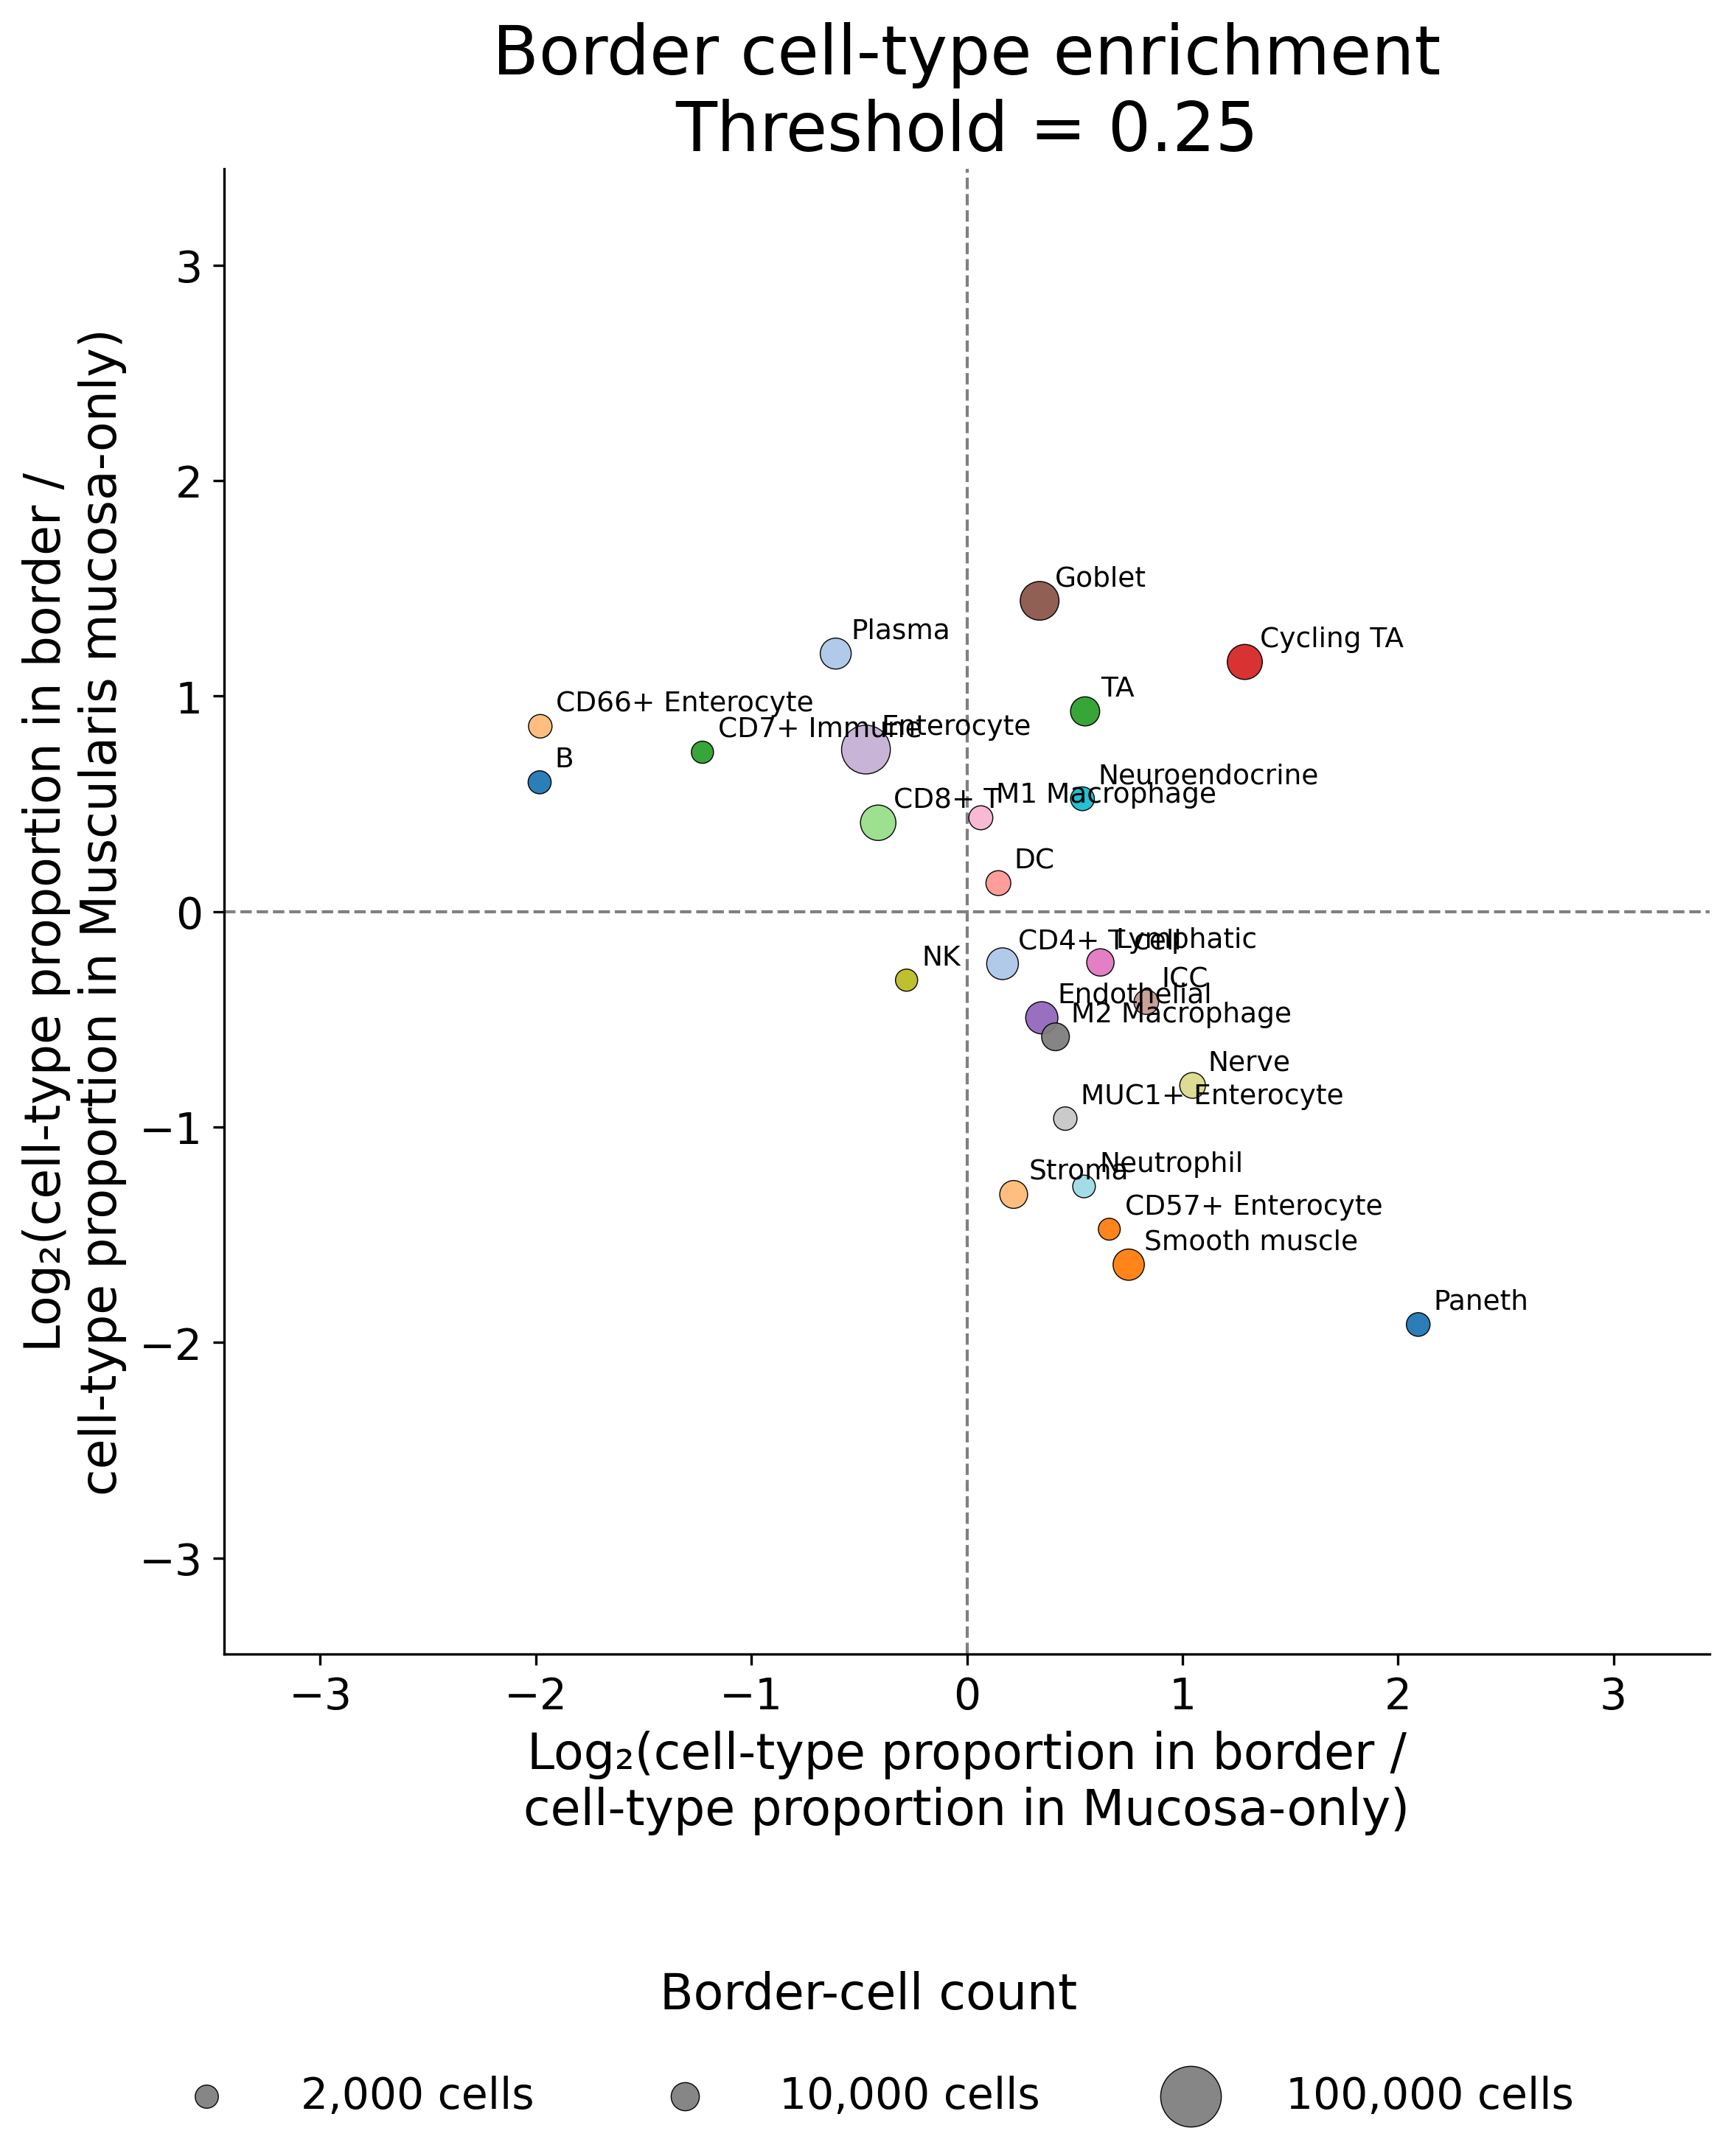

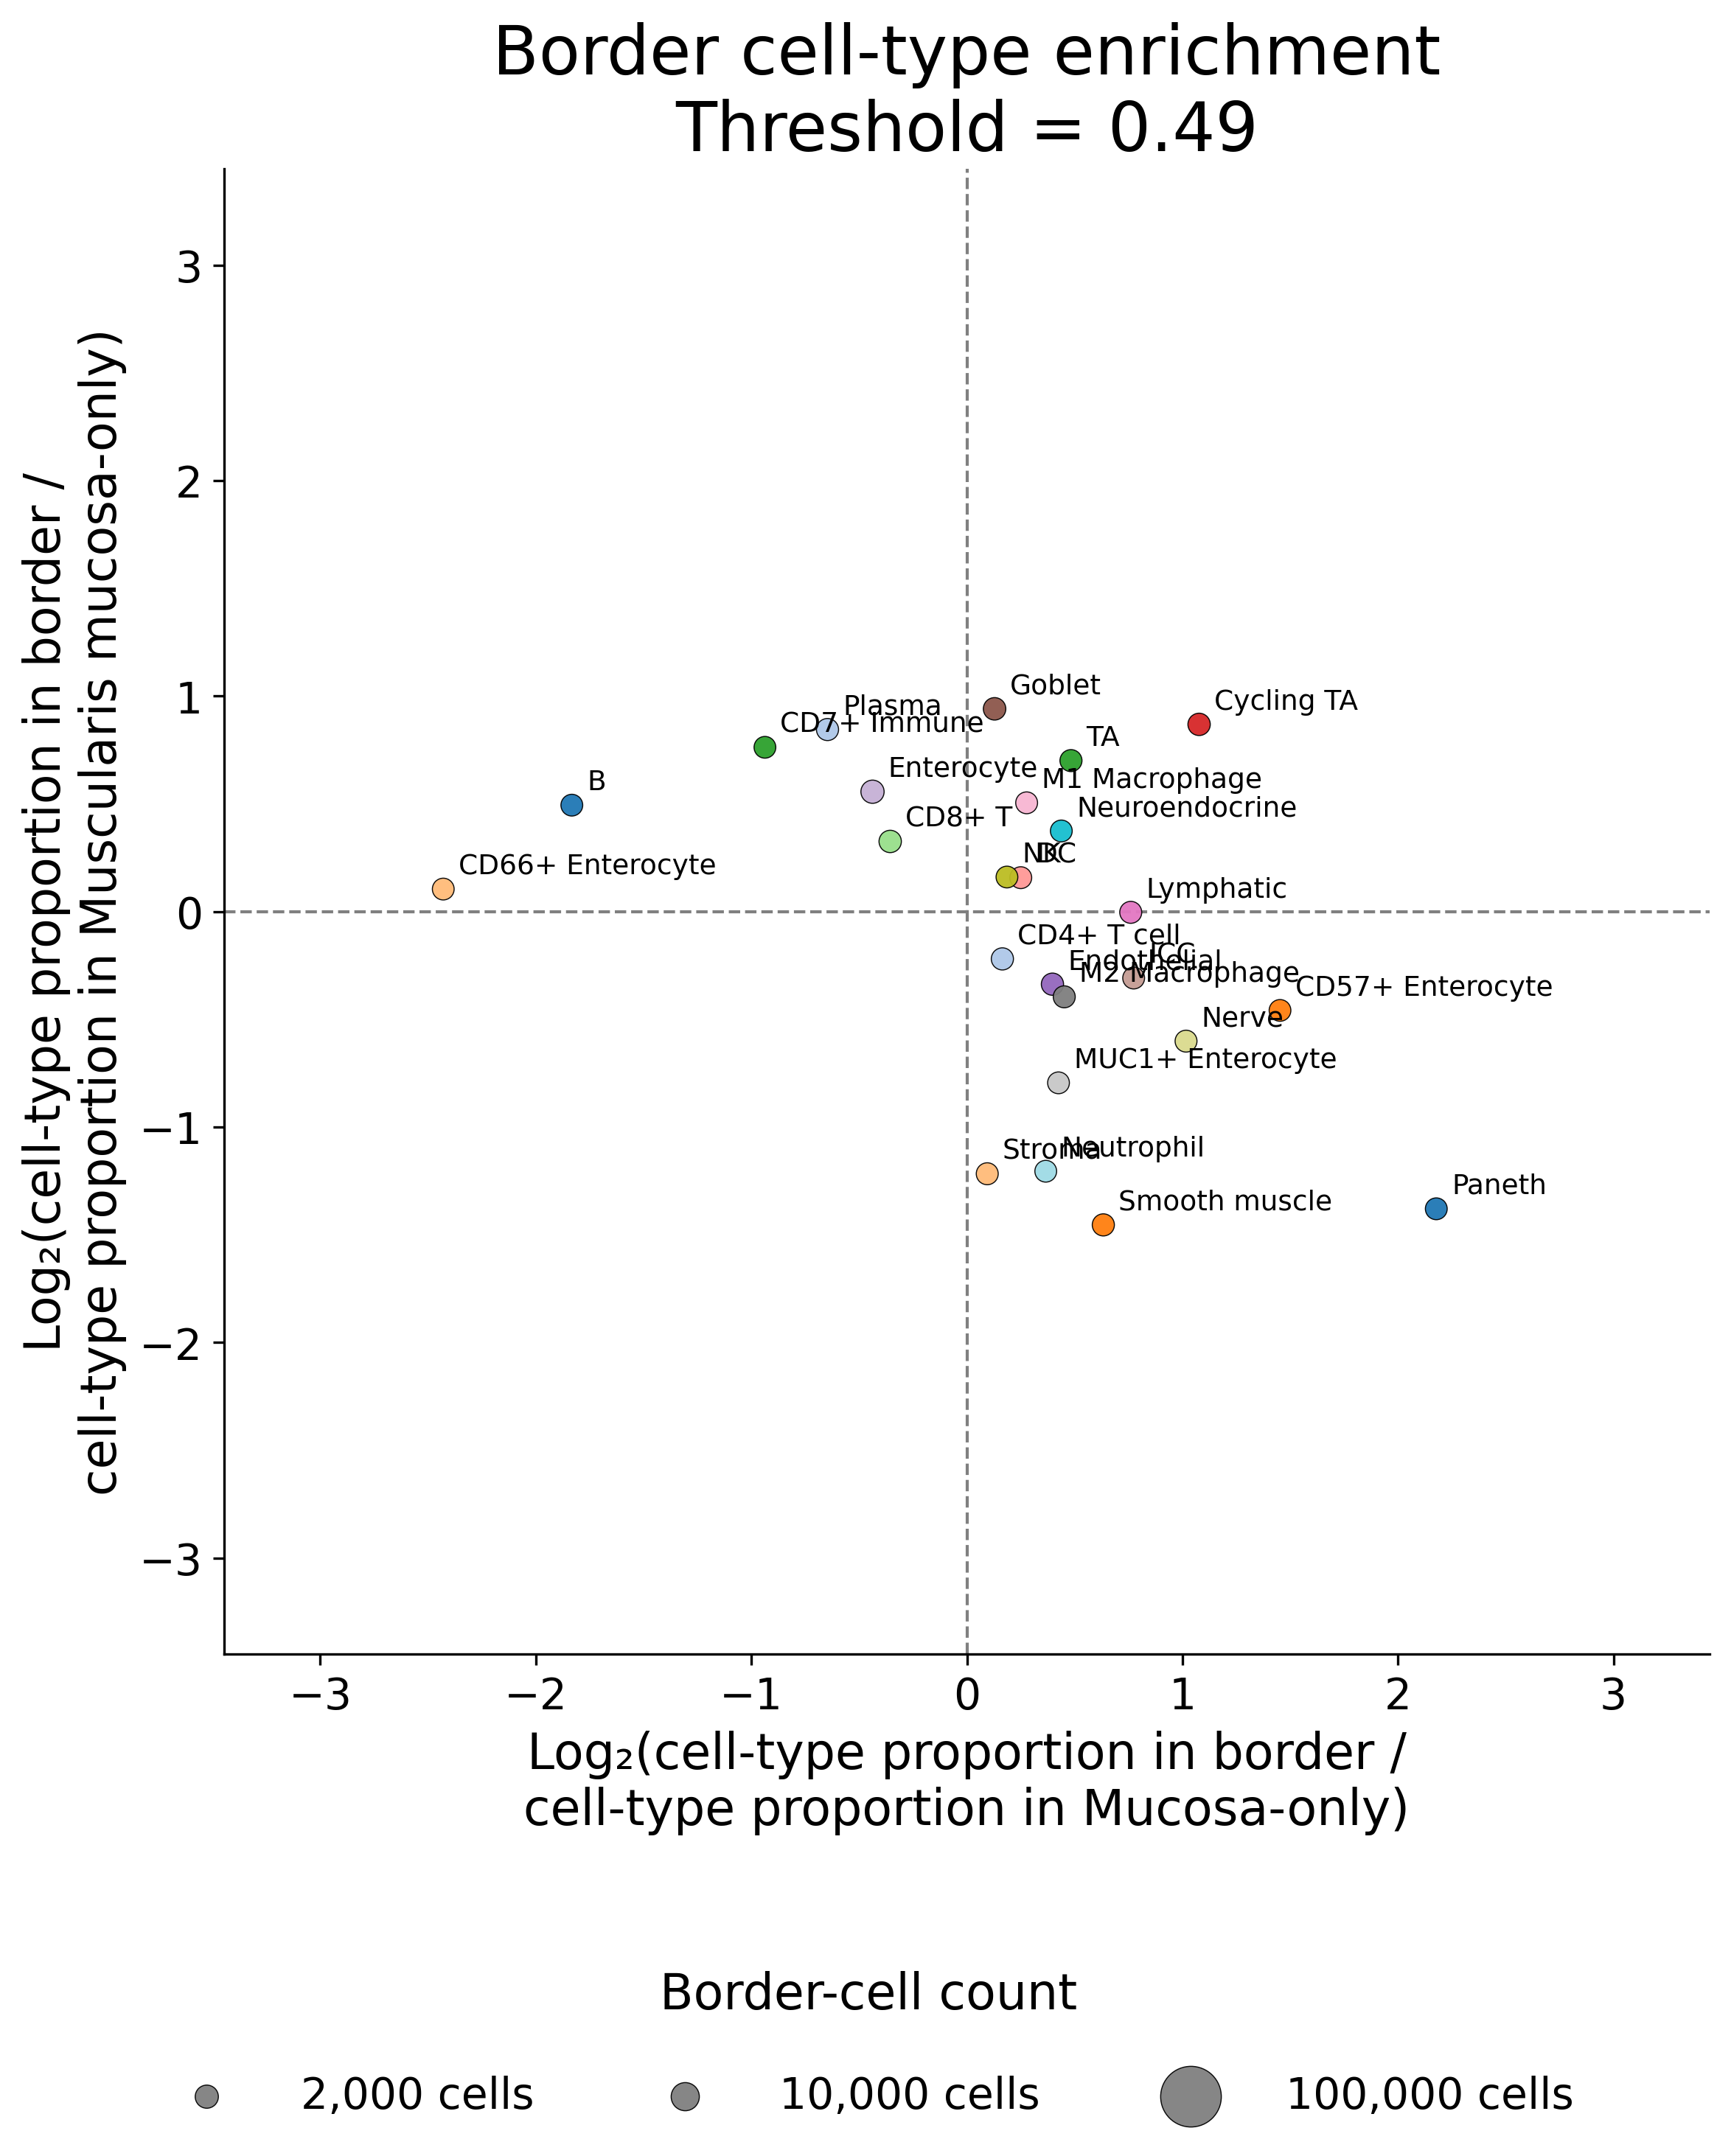

In [53]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex

OUTPUT = Path(OUTPUT)
SCATTER_DIR = OUTPUT / "enrichment_quadrant_plots"
SCATTER_DIR.mkdir(parents=True, exist_ok=True)

PLOT_THRESHOLDS = [0.01, 0.10, 0.20, 0.25, 0.49]
MIN_COUNT = 5  # Match your original manuscript setting.

LEGEND_COUNTS = [2000, 10000, 100000]
MIN_AREA = 50.0
MAX_AREA = 800.0

LABEL_DOTS = True
LABEL_FONT_SIZE = 9

data = pd.read_csv(OUTPUT / "tissue_unit_enrichment_full.csv")

if data[["cn1", "cn2"]].drop_duplicates().shape[0] != 1:
    raise ValueError("Select one neighborhood pair before plotting.")

N1 = str(data["cn1"].iloc[0])
N2 = str(data["cn2"].iloc[0])

# Select thresholds and apply the original per-threshold filter.
blocks = []

for threshold in PLOT_THRESHOLDS:
    block = data.loc[
        np.isclose(data["threshold"], threshold, atol=1e-10, rtol=0)
    ].copy()

    if block.empty:
        raise ValueError(f"No saved data for threshold {threshold}.")

    block["threshold"] = threshold

    eligible = (
        block[["count_cn1_only", "count_border", "count_cn2_only"]]
        .ge(MIN_COUNT)
        .all(axis=1)
        & np.isfinite(
            block[["enrichment_cn1", "enrichment_cn2"]]
        ).all(axis=1)
    )

    blocks.append(block.loc[eligible])

plot_data = pd.concat(blocks, ignore_index=True)

if plot_data.empty:
    raise ValueError("No cell types pass the count filter.")

if plot_data.duplicated(["threshold", "cell_type"]).any():
    raise ValueError("Duplicate cell-type/threshold rows.")

# Reuse your cell-type palette when available.
palette = {
    str(key): value
    for key, value in globals().get("color_dict", {}).items()
}

cell_type_names = sorted(plot_data["cell_type"].unique())
fallback = plt.get_cmap("tab20")

for i, cell_type in enumerate(cell_type_names):
    palette.setdefault(cell_type, fallback(i % 20))

# Save the palette actually used.
pd.DataFrame({
    "cell_type": cell_type_names,
    "color": [to_hex(palette[ct]) for ct in cell_type_names],
}).to_csv(SCATTER_DIR / "cell_type_colors.csv", index=False)

# Same dot-area formula as the package, with one shared maximum.
scale_max = max(
    float(plot_data["count_border"].max()),
    max(LEGEND_COUNTS),
    1,
)

def count_to_area(count):
    count = np.asarray(count, dtype=float)
    return MIN_AREA + (count / scale_max) * (MAX_AREA - MIN_AREA)

# Shared symmetric limits keep all four quadrants visible.
coordinate_max = np.abs(
    plot_data[["enrichment_cn1", "enrichment_cn2"]].to_numpy()
).max()

axis_limit = max(1.0, float(coordinate_max) * 1.20)

plot_data.to_csv(
    SCATTER_DIR / "plotted_enrichment_values.csv",
    index=False,
)

for threshold in PLOT_THRESHOLDS:
    subset = plot_data.loc[
        plot_data["threshold"] == threshold
    ].copy()

    if subset.empty:
        print(f"Skipping {threshold:g}: no eligible cell types.")
        continue

    # Draw larger dots first so smaller dots remain visible.
    subset = subset.sort_values("count_border", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

    ax.axhline(
        0, color="gray", linestyle="--", linewidth=1, zorder=0
    )
    ax.axvline(
        0, color="gray", linestyle="--", linewidth=1, zorder=0
    )

    ax.scatter(
        subset["enrichment_cn1"],
        subset["enrichment_cn2"],
        s=count_to_area(subset["count_border"]),
        c=[palette[ct] for ct in subset["cell_type"]],
        edgecolors="black",
        linewidths=0.35,
        alpha=0.95,
        zorder=3,
    )

    if LABEL_DOTS:
        for row in subset.itertuples(index=False):
            ax.annotate(
                row.cell_type,
                (row.enrichment_cn1, row.enrichment_cn2),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=LABEL_FONT_SIZE,
                zorder=4,
            )

    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(
        f"Log₂(cell-type proportion in border /\n"
        f"cell-type proportion in {N1}-only)",
        fontsize=16,
    )
    ax.set_ylabel(
        f"Log₂(cell-type proportion in border /\n"
        f"cell-type proportion in {N2}-only)",
        fontsize=16,
    )
    ax.set_title(
        f"Border cell-type enrichment\nThreshold = {threshold:g}",
        fontsize=22,
    )

    ax.tick_params(labelsize=14)
    ax.spines[["top", "right"]].set_visible(False)

    # Scatter handles use exactly the same area scale as plotted dots.
    size_handles = [
        ax.scatter(
            [], [],
            s=float(count_to_area(count)),
            color="gray",
            edgecolors="black",
            linewidths=0.35,
            alpha=0.95,
            label=f"{count:,} cells",
        )
        for count in LEGEND_COUNTS
    ]

    # Embedded legend in a reserved strip below the plot.
    fig.legend(
        handles=size_handles,
        title="Border-cell count",
        loc="lower center",
        bbox_to_anchor=(0.5, 0.02),
        ncol=len(LEGEND_COUNTS),
        frameon=False,
        fontsize=14,
        title_fontsize=16,
        labelspacing=1.3,
        columnspacing=2.5,
        handletextpad=1.2,
    )

    fig.tight_layout(rect=(0, 0.15, 1, 1))

    stem = f"border_enrichment_threshold_{threshold:g}"

    fig.savefig(
        SCATTER_DIR / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )
    fig.savefig(
        SCATTER_DIR / f"{stem}.pdf",
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)